In [1]:
import sys
import os
sys.path.append(os.getcwd())
import risk_utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm

# Импорт библиотек

In [2]:
import pandas as pd
import requests
import time
from typing import List
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.optimize import minimize

# 1. Собрать данные о ежедневных ценах закрытия 30 российских акций за период с 01.01.2015 по 31.12.2025.

## Код сбора данных

**Первоисточник данных:**  
**Московская Биржа (MOEX)**

**Полный путь происхождения данных:**

Участники рынка заключают сделки на Московской Бирже, все сделки фиксируются в торговой системе МОЭКС.
Далее биржа самостоятельно агрегирует сделки в **дневные свечи** (OHLCV) , потом агрегированные данные публикуются через официальный **API ISS MOEX** (`https://iss.moex.com/iss`).Код обращается напрямую к этому API с помощью библиотеки `requests`, полученные JSON-ответы преобразуются в датафрейм


Код, который ниже берёт 80 самых ликвидных акций, проверяет качество исторических данных для каждой. Потом смотрит, чтобы история покрывала не менее 90% от максимальной длины периода, доля пропусков не более 5%. Потом сортирует по ликвидности и выбирает **лучшие 30 акций**.

In [3]:
# import requests
# import pandas as pd
# import time

# base_url = "https://iss.moex.com/iss"
# start_dt = "2015-01-01"
# end_dt = "2025-12-31"

# session = requests.Session()
# session.headers.update({"User-Agent": "moex-portfolio-project/1.0"})


# def uni_moex_stocks():
#     # какие акции сейчас есть на мосбирже и как они торгуются
#     url = f"{base_url}/engines/stock/markets/shares/boards/TQBR/securities.json"
#     j = session.get(url, timeout=30).json()

#     sec = pd.DataFrame(j["securities"]["data"], columns=j["securities"]["columns"])
#     md = pd.DataFrame(j["marketdata"]["data"], columns=j["marketdata"]["columns"])

#     df = sec.merge(md, on=["SECID", "BOARDID"], how="left", suffixes=("", "_MD"))
#     return df


# def get_candles(ticker, start_date=start_dt, end_date=end_dt, interval=24):
#     # дневные свечи по одной бумаге
#     url = f"{base_url}/engines/stock/markets/shares/securities/{ticker}/candles.json"

#     parts = []
#     start = 0

#     while True:
#         params = {
#             "from": start_date,
#             "till": end_date,
#             "interval": interval,
#             "start": start,
#         }

#         r = session.get(url, params=params, timeout=30)
#         r.raise_for_status()
#         j = r.json()

#         candles = j.get("candles", {})
#         cols = candles.get("columns", [])
#         data = candles.get("data", [])

#         if not data:
#             break

#         chunk = pd.DataFrame(data, columns=cols)
#         chunk["ticker"] = ticker
#         parts.append(chunk)

#         if len(data) < 100:
#             break

#         start += len(data)
#         time.sleep(0.15)

#     if not parts:
#         return pd.DataFrame()

#     df = pd.concat(parts, ignore_index=True)
#     return df


# def build_candidate_list(top_n=80):
#     """
#     Формируем список кандидатов:
#     - активные бумаги
#     - по возможности акции
#     - сортировка по ликвидности
#     """
#     universe = uni_moex_stocks().copy()

#     # Базовый фильтр: активные бумаги
#     if "STATUS" in universe.columns:
#         universe = universe[universe["STATUS"] == "A"].copy()

#     # Оставляем только equity-инструменты, если поле есть
#     if "INSTRID" in universe.columns:
#         universe = universe[universe["INSTRID"] == "EQIN"].copy()

#     # Убираем явный мусор по названию, если встретится
#     if "SHORTNAME" in universe.columns:
#         bad_words = ["ПАЙ", "ETF", "БПИФ", "ИПИФ", "ОБЛ", "OFZ"]
#         mask_bad = universe["SHORTNAME"].fillna("").str.upper().str.contains("|".join(bad_words), regex=True)
#         universe = universe[~mask_bad].copy()

#     # Выбираем метрику ликвидности
#     liquidity_col = None
#     for col in ["VALTODAY_RUR", "VALTODAY", "VALUE"]:
#         if col in universe.columns:
#             liquidity_col = col
#             break

#     if liquidity_col is None:
#         universe["liquidity_proxy"] = 0
#         liquidity_col = "liquidity_proxy"

#     universe[liquidity_col] = pd.to_numeric(universe[liquidity_col], errors="coerce")
#     universe = universe.sort_values(liquidity_col, ascending=False)

#     cols_to_keep = [
#         c for c in [
#             "SECID", "SHORTNAME", "STATUS", "INSTRID", "SECTYPE",
#             "LISTLEVEL", "ISSUECAPITALIZATION", "VALTODAY_RUR", "VALTODAY", "VALUE"
#         ]
#         if c in universe.columns
#     ]

#     return universe[cols_to_keep].head(top_n).reset_index(drop=True)


# def history_quality_report(tickers):
#     """
#     Для каждого тикера считаем качество истории.
#     """
#     reports = []

#     for i, ticker in enumerate(tickers, 1):
#         print(f"[{i}/{len(tickers)}] чекаем {ticker}")
#         try:
#             df = get_candles(ticker)

#             if df.empty:
#                 reports.append({
#                     "ticker": ticker,
#                     "first_date": pd.NaT,
#                     "last_date": pd.NaT,
#                     "obs": 0,
#                     "close_na_share": 1.0,
#                 })
#                 continue

#             if "begin" in df.columns:
#                 df["begin"] = pd.to_datetime(df["begin"], errors="coerce")

#             if "close" in df.columns:
#                 df["close"] = pd.to_numeric(df["close"], errors="coerce")

#             reports.append({
#                 "ticker": ticker,
#                 "first_date": df["begin"].min() if "begin" in df.columns else pd.NaT,
#                 "last_date": df["begin"].max() if "begin" in df.columns else pd.NaT,
#                 "obs": len(df),
#                 "close_na_share": df["close"].isna().mean() if "close" in df.columns else 1.0,
#             })

#         except Exception as e:
#             print(f"  Ошибка {ticker}: {e}")
#             reports.append({
#                 "ticker": ticker,
#                 "first_date": pd.NaT,
#                 "last_date": pd.NaT,
#                 "obs": 0,
#                 "close_na_share": 1.0,
#             })

#         time.sleep(0.2)

#     return pd.DataFrame(reports)


# def select_good_30(exclude_tickers=None):
#     """
#     Полный автоматический отбор 30 хороших акций.
#     exclude_tickers - список тикеров, которые надо исключить.
#     """
#     if exclude_tickers is None:
#         exclude_tickers = []

#     # берем кандидатов
#     candidates = build_candidate_list(top_n=80)
#     tickers = candidates["SECID"].tolist()

#     # проверяем историю
#     quality = history_quality_report(tickers)

#     # Объединяем
#     result = candidates.merge(quality, left_on="SECID", right_on="ticker", how="left")
#     result = result.drop(columns=["ticker"])

#     max_obs = result["obs"].max()
#     min_obs_threshold = int(max_obs * 0.90)

#     # Фильтр качества
#     good = result[
#         (result["obs"] >= min_obs_threshold) &
#         (result["close_na_share"] <= 0.05) &
#         (result["first_date"] <= pd.Timestamp("2015-03-01")) &
#         (result["last_date"] >= pd.Timestamp("2025-12-01"))
#     ].copy()

#     if exclude_tickers:
#         good = good[~good["SECID"].isin(exclude_tickers)].copy()

#     # cортировка по ликвидности
#     sort_cols = [c for c in ["VALTODAY_RUR", "VALTODAY", "VALUE", "ISSUECAPITALIZATION"] if c in good.columns]
#     if sort_cols:
#         good = good.sort_values(sort_cols, ascending=False)
#     else:
#         good = good.sort_values("obs", ascending=False)

#     # Берем первые 30
#     final30 = good.head(30).reset_index(drop=True)

#     return candidates, quality, result, final30


# candidates, quality, result, final30 = select_good_30(exclude_tickers=["IRAO"])

# print("\nИтоговые 30 акций:")
# print(final30[["SECID", "SHORTNAME", "first_date", "last_date", "obs"]])

# # Список тикеров для дальнейшей загрузки
# final_tickers = final30["SECID"].tolist()
# print("\nФинальный список тикеров:")
# print(final_tickers)

# tickers = final30["SECID"].tolist()
# final30.to_csv("moex_final30.csv", index=False, encoding="utf-8-sig")

Далее блок, где для каждого из 30 тикеров последовательно запрашивает дневные свечи (`interval=24`) через API MOEX. Оставляет только нужные колонки (`date`, `ticker`, `close` и др.).
Переводит таблицу из длинного формата (`long`) в широкий (`wide`), где: строки — даты, столбцы — тикеры, значения — цены закрытия

In [4]:
import requests
import pandas as pd
import time

In [5]:
BASE_URL = "https://iss.moex.com/iss"
START_DATE = "2014-12-31"
END_DATE = "2025-12-31"



In [6]:



session = requests.Session()
session.headers.update({"User-Agent": "moex-portfolio-project/1.0"})


def get_moex_candles(ticker, start_date, end_date, interval=24):
    """
    Скачивает дневные свечи по одной акции с MOEX ISS
    """
    url = f"{BASE_URL}/engines/stock/markets/shares/securities/{ticker}/candles.json"

    all_rows = []
    start = 0

    while True:
        params = {
            "from": start_date,
            "till": end_date,
            "interval": interval,
            "start": start
        }

        response = session.get(url, params=params, timeout=30)
        response.raise_for_status()
        j = response.json()

        candles = j.get("candles", {})
        columns = candles.get("columns", [])
        data = candles.get("data", [])

        if not data:
            break

        chunk = pd.DataFrame(data, columns=columns)
        chunk["ticker"] = ticker
        all_rows.append(chunk)

        if len(data) < 100:
            break

        start += len(data)
        time.sleep(0.2)

    if not all_rows:
        return pd.DataFrame()

    df = pd.concat(all_rows, ignore_index=True)
    return df


def load_all_tickers(tickers, start_date, end_date):
    """
    Скачивает данные по списку тикеров и собирает в одну таблицу
    """
    frames = []

    for i, ticker in enumerate(tickers, 1):
        print(f"[{i}/{len(tickers)}] Загружаю {ticker}...")
        try:
            df = get_moex_candles(ticker, start_date, end_date)

            if df.empty:
                print(f"  Нет данных по {ticker}")
                continue

            frames.append(df)

        except Exception as e:
            print(f"  Ошибка для {ticker}: {e}")

        time.sleep(0.3)

    if not frames:
        return pd.DataFrame()

    result = pd.concat(frames, ignore_index=True)
    return result




## Код чтения датасета

In [7]:
close_prices_wide = pd.read_csv('moex_close_prices_wide_2015_2025.csv', index_col='date', parse_dates=['date'])
close_prices_wide

,AFKS,AFLT,ALRS,BSPB,CHMF,GAZP,GMKN,LKOH,MAGN,MGNT,...,SBER,SBERP,SELG,SIBN,SNGS,SNGSP,TATN,TATNP,TRNFP,VTBR
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,12.250,33.21,60.38,24.60,522.00,133.95,85.90,2295.0,11.279,9877.0,...,56.37,38.59,4.595,142.00,24.240,29.600,238.00,134.7,1301.0,337.50
2015-01-06,12.370,33.07,61.28,25.60,556.90,138.92,91.01,2345.0,11.550,10400.0,...,58.28,39.50,4.500,144.60,25.015,30.195,228.75,135.3,1429.9,333.30
2015-01-08,12.600,35.17,60.20,26.50,542.70,146.46,95.50,2572.0,12.350,10627.0,...,65.70,43.75,4.595,148.10,26.265,31.600,245.00,136.0,1300.0,337.05
2015-01-09,12.610,34.00,61.91,26.15,548.55,141.70,97.40,2461.0,12.100,10542.0,...,63.10,42.90,4.555,146.60,25.650,32.010,234.05,134.5,1208.2,326.55
2015-01-12,12.130,34.45,63.00,25.70,558.45,140.22,98.39,2477.0,11.893,10689.0,...,62.90,42.41,4.650,143.10,25.450,31.360,228.25,133.3,1280.0,317.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,13.197,57.87,42.36,310.73,965.80,125.04,145.72,5677.5,28.020,3036.5,...,302.03,299.84,44.700,487.55,22.135,41.220,572.90,531.2,1353.8,71.60
2025-12-25,13.087,56.90,42.34,311.04,964.20,124.20,147.16,5673.5,27.895,3001.0,...,300.26,297.62,43.850,482.10,21.920,40.600,568.80,529.4,1349.6,71.40
2025-12-26,13.337,58.85,43.00,313.42,980.00,127.37,152.00,5790.0,28.550,3042.5,...,302.51,300.09,44.400,489.00,22.150,40.780,584.30,541.0,1390.8,72.92


# 2. Рассчитать для отобранных акций векторы доходностей и ковариационные матрицы на различные даты

### 2.1 Матрица доходностей

Доходность акции в момент времени $t$ определяется как

$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$

где $P_t$ — цена закрытия в день $t$

In [8]:
close_prices_wide = close_prices_wide.sort_index() # для начала отсортируем даты
returns = close_prices_wide.pct_change() # считаем простые дневные доходности
returns = returns.iloc[1:].copy()

display("Размер матрицы доходностей:", returns.shape)
display(returns.head())


'Размер матрицы доходностей:'

(2753, 30)

,AFKS,AFLT,ALRS,BSPB,CHMF,GAZP,GMKN,LKOH,MAGN,MGNT,...,SBER,SBERP,SELG,SIBN,SNGS,SNGSP,TATN,TATNP,TRNFP,VTBR
date,,,,,,,,,,,,,,,,,,,,,
2015-01-06,0.009796,-0.004216,0.014906,0.040650,0.066858,0.037103,0.059488,0.021786,0.024027,0.052951,...,0.033883,0.023581,-0.020675,0.018310,0.031972,0.020101,-0.038866,0.004454,0.099078,-0.012444
2015-01-08,0.018593,0.063502,-0.017624,0.035156,-0.025498,0.054276,0.049335,0.096802,0.069264,0.021827,...,0.127316,0.107595,0.021111,0.024205,0.049970,0.046531,0.071038,0.005174,-0.090846,0.011251
2015-01-09,0.000794,-0.033267,0.028405,-0.013208,0.010779,-0.032500,0.019895,-0.043157,-0.020243,-0.007998,...,-0.039574,-0.019429,-0.008705,-0.010128,-0.023415,0.012975,-0.044694,-0.011029,-0.070615,-0.031153
2015-01-12,-0.038065,0.013235,0.017606,-0.017208,0.018048,-0.010445,0.010164,0.006501,-0.017107,0.013944,...,-0.003170,-0.011422,0.020856,-0.023874,-0.007797,-0.020306,-0.024781,-0.008922,0.059427,-0.027255
2015-01-13,0.009893,0.015965,0.053968,-0.005837,0.043961,0.017259,0.018904,0.018167,0.040948,0.045935,...,-0.041176,-0.037491,0.009677,0.004892,0.005894,0.029974,0.028258,0.003751,0.023359,-0.047694


In [9]:
(returns.groupby(returns.index.to_period("W")).size()).mean()

np.float64(4.8213660245183885)

## Расчет доходностей и ковариаций

В данном блоке рассчитываются:

- вектор средних доходностей \($mu_t$);
- ковариационная матрица \($Sigma_t$);

для набора акций на разные даты.

### Подход

Расчеты выполняются на выбранных датах (год, квартал, месяц и т.д.) двумя способами:

1. **Скользящее окно**  
   Используются только последние наблюдения фиксированной длины (например, 1 год ≈ 252 дня).

2. **Расширяющееся окно**  
   Используются все доступные данные от начала выборки до текущей даты.

---

### Оценки

Для каждого окна считаются:

- средние доходности (вектор \($mu_t$));
- ковариации доходностей (матрица \($Sigma_t$)).

---

### Взвешивание

Рассматриваются два варианта:

- **без весов** — все наблюдения равнозначны;
- **с экспоненциальным забыванием** — более свежие данные имеют больший вес (параметр \($lambda$)).

---

### Структура кода

- `get_rebalance_dates` — выбирает даты расчета;
- `mean_cov_unweighted` — обычные оценки;
- `mean_cov_ew` — оценки с экспоненциальным забыванием;
- `rolling_mean_cov` — расчеты на скользящем окне;
- `expanding_mean_cov` — расчеты на расширяющемся окне.

In [10]:
def get_rebalance_dates(index, step="Y"):
    """
    Выбирает даты, на которых считаем mu и Sigma.
    'Y'  - конец года
    'Q'  - конец квартала
    'M'  - конец месяца
    'W'  - конец недели
    'D'  - каждый день
    """
    idx = pd.DatetimeIndex(index)

    if step == "D":
        return idx

    s = pd.Series(index=idx, data=1)
    dates = s.resample(step).last().dropna().index
    return dates

# Обычные mean/cov на заданном окне

def mean_cov_unweighted(window_returns):
    """
    window_returns: DataFrame (T x N)
    Возвращает:
        mu    : Series (N,)
        Sigma : DataFrame (N x N)
    """
    mu = window_returns.mean()
    Sigma = window_returns.cov()
    return mu, Sigma

# Mean/cov с экспоненциальным забыванием

def exp_weights(n, lam=0.94):
    """
    n - число наблюдений
    lam - коэффициент забывания
    Вес самого свежего наблюдения максимален
    """
    # k=0 для самого старого, поэтому развернем позже
    w = np.array([lam**k for k in range(n-1, -1, -1)], dtype=float)
    w /= w.sum()
    return w

def mean_cov_ew(window_returns, lam=0.94):
    """
    Экспоненциально-взвешенные mean и covariance
    """
    X = window_returns.values  # shape (T, N)
    n, m = X.shape

    w = exp_weights(n, lam=lam)  # shape (T,)

    mu = np.sum(X * w[:, None], axis=0)  # shape (N,)
    X_centered = X - mu

    Sigma = (X_centered * w[:, None]).T @ X_centered

    mu = pd.Series(mu, index=window_returns.columns, name="mu")
    Sigma = pd.DataFrame(Sigma, index=window_returns.columns, columns=window_returns.columns)

    return mu, Sigma


# Скользящее окно длиной 1 год

def rolling_mean_cov(
    returns,
    window_days=252,
    step="Y",
    weighted=False,
    lam=0.94
):

    rebalance_dates = get_rebalance_dates(returns.index, step=step)

    mus = {}
    covs = {}

    for dt in rebalance_dates:
        # Берем все данные до dt включительно
        sub = returns.loc[:dt]
        if len(sub) < window_days:
            continue

        window = sub.iloc[-window_days:]

        if weighted:
            mu, Sigma = mean_cov_ew(window, lam=lam)
        else:
            mu, Sigma = mean_cov_unweighted(window)

        mus[dt] = mu
        covs[dt] = Sigma

    return mus, covs


# Расшир окно

def expanding_mean_cov(
    returns,
    min_days = 252,
    step = "Y",
    weighted=False,
    lam = 0.94
):
    """
    expanding window: от начала выборки до даты dt
    min_days: минимальное число наблюдений перед первым расчетом
    """
    rebalance_dates = get_rebalance_dates(returns.index, step=step)

    mus = {}
    covs = {}

    for dt in rebalance_dates:
        window = returns.loc[:dt]

        if len(window) < min_days:
            continue

        if weighted:
            mu, Sigma = mean_cov_ew(window, lam=lam)
        else:
            mu, Sigma = mean_cov_unweighted(window)

        mus[dt] = mu
        covs[dt] = Sigma

    return mus, covs

Скользящее окно 1 год, шаг 1 год

In [11]:
mus_roll_y, covs_roll_y = rolling_mean_cov(
    returns,
    window_days=252,   # примерно 1 торговый год, брал среднее по всем торговым годам, которые попали в выборку
    step="YE",
    weighted=False
)
display(mus_roll_y)

{Timestamp('2016-12-31 00:00:00'): AFKS     0.001205
 AFLT     0.004196
 ALRS     0.002425
 BSPB     0.001786
 CHMF     0.001872
 GAZP     0.000565
 GMKN     0.000495
 LKOH     0.001645
 MAGN     0.002682
 MGNT     0.000195
 MOEX     0.001336
 MTLR     0.004659
 MTSS     0.000919
 MVID     0.001812
 NLMK     0.002613
 NVTK     0.001224
 PHOR    -0.000231
 PIKK     0.001193
 PLZL     0.001779
 ROSN     0.001960
 SBER     0.002272
 SBERP    0.002227
 SELG     0.003509
 SIBN     0.001369
 SNGS    -0.000342
 SNGSP   -0.001110
 TATN     0.001318
 TATNP    0.000863
 TRNFP    0.000500
 VTBR    -0.000100
 dtype: float64,
 Timestamp('2017-12-31 00:00:00'): AFKS    -0.001632
 AFLT    -0.000196
 ALRS    -0.000882
 BSPB    -0.000682
 CHMF    -0.000119
 GAZP    -0.000610
 GMKN     0.000388
 LKOH    -0.000049
 MAGN     0.001087
 MGNT    -0.002000
 MOEX    -0.000412
 MTLR    -0.000466
 MTSS     0.000407
 MVID     0.000354
 NLMK     0.001117
 NVTK    -0.000529
 PHOR    -0.000067
 PIKK     0.000574
 PL

Скользящее окно 1 квартал / 1 месяц / 1 неделя / 1 день

In [12]:
mus_roll_q, covs_roll_q = rolling_mean_cov(returns, window_days=63, step="QE", weighted=False)
mus_roll_m, covs_roll_m = rolling_mean_cov(returns, window_days=21, step="ME", weighted=False)
mus_roll_w, covs_roll_w = rolling_mean_cov(returns, window_days=5,  step="W", weighted=False)
mus_roll_d, covs_roll_d = rolling_mean_cov(returns, window_days=1,  step="D", weighted=False)

/home/andrn/miniconda3/envs/flux_test/lib/python3.14/site-packages/pandas/core/frame.py:13284: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/home/andrn/miniconda3/envs/flux_test/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/andrn/miniconda3/envs/flux_test/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Расширяющееся окно, шаг 1 год

In [13]:
mus_exp_y, covs_exp_y = expanding_mean_cov(
    returns,
    min_days=252,
    step="YE",
    weighted=False
)

# 3. (*) Выполнить п. 2 для схемы взвешивания наблюдений с экспоненциальным забыванием.


То же, но с экспоненциальным забыванием

In [14]:
mus_roll_y_ew, covs_roll_y_ew = rolling_mean_cov(
    returns,
    window_days=252,
    step="YE",
    weighted=True,
    lam=0.94
)

mus_exp_y_ew, covs_exp_y_ew = expanding_mean_cov(
    returns,
    min_days=252,
    step="YE",
    weighted=True,
    lam=0.94
)

In [15]:
# векторы доходностей
mu_table = pd.DataFrame(mus_roll_y).T
mu_table.index.name = "Date"
print(mu_table.head())

# пример ковариационной матрицы
some_date = list(covs_roll_y.keys())[0]
print("Дата:", some_date)
print(covs_roll_y[some_date])

                AFKS      AFLT      ALRS      BSPB      CHMF      GAZP  \
Date                                                                     
2016-12-31  0.001205  0.004196  0.002425  0.001786  0.001872  0.000565   
2017-12-31 -0.001632 -0.000196 -0.000882 -0.000682 -0.000119 -0.000610   
2018-12-31 -0.001510 -0.001075  0.001180 -0.000836  0.000324  0.000750   
2019-12-31  0.002677  0.000165 -0.000508  0.001114  0.000070  0.002219   
2020-12-31  0.002913 -0.001130  0.000927  0.000207  0.001537 -0.000524   

                GMKN      LKOH          MAGN      MGNT  ...      SBER  \
Date                                                    ...             
2016-12-31  0.000495  0.001645  2.681743e-03  0.000195  ...  0.002272   
2017-12-31  0.000388 -0.000049  1.086753e-03 -0.002000  ...  0.001153   
2018-12-31  0.000980  0.001723  1.806925e-04 -0.002125  ... -0.000462   
2019-12-31  0.001595  0.000946  3.426455e-07  0.000021  ...  0.001322   
2020-12-31  0.001103 -0.000242  1.393765e-0

In [16]:
# сохраним в эксель
with pd.ExcelWriter("results.xlsx") as writer:
    pd.DataFrame(mus_roll_y).T.to_excel(writer, sheet_name="mu_roll_y")
    pd.DataFrame(mus_exp_y).T.to_excel(writer, sheet_name="mu_expand_y")
    pd.DataFrame(mus_roll_y_ew).T.to_excel(writer, sheet_name="mu_roll_y_ew")
    pd.DataFrame(mus_exp_y_ew).T.to_excel(writer, sheet_name="mu_expand_y_ew")


    for dt, cov in covs_roll_y.items():
        sheet = f"cov_roll_{dt.strftime('%Y%m%d')}"[:31]
        cov.to_excel(writer, sheet_name=sheet)

    for dt, cov in covs_exp_y.items():
        sheet = f"cov_exp_{dt.strftime('%Y%m%d')}"[:31]
        cov.to_excel(writer, sheet_name=sheet)

    for dt, cov in covs_roll_y_ew.items():
        sheet = f"cov_roll_ew_{dt.strftime('%Y%m%d')}"[:31]
        cov.to_excel(writer, sheet_name=sheet)

    for dt, cov in covs_exp_y_ew.items():
        sheet = f"cov_exp_ew_{dt.strftime('%Y%m%d')}"[:31]
        cov.to_excel(writer, sheet_name=sheet)

# 4. Выбрать одно историческое окно и схему взвешивания наблюдений для последующего расчёта границы эффективных портфелей для различных ограничений.

Для исследования влияния ограничений на границу эффективных портфелей выбрано годовое окно по следующим причинам:

1. Достаточное количество наблюдений. При 30 акциях для устойчивой оценки ковариационной матрицы требуется не менее 90–150 наблюдений. Годовое окно дает 252 торговых дня. Квартальное (63 дня), месячное (21 день) и недельное (5 дней) окна содержат недостаточно данных.

2. Высокая точность оценок. Погрешность оценки обратно пропорциональна √T. Чем короче окно, тем менее точны оценки.

3. Стабильность ковариационной матрицы. Годовое окно дает наименьшее число обусловленности, что означает устойчивость матрицы к малым изменениям данных.


In [17]:
xl = pd.ExcelFile("results.xlsx")

mu_roll = pd.read_excel("results.xlsx", sheet_name="mu_roll_y", index_col=0)          # скользящее + равные
mu_expand = pd.read_excel("results.xlsx", sheet_name="mu_expand_y", index_col=0)      # расширяющееся + равные
mu_roll_ew = pd.read_excel("results.xlsx", sheet_name="mu_roll_y_ew", index_col=0)    # скользящее + эксп
mu_expand_ew = pd.read_excel("results.xlsx", sheet_name="mu_expand_y_ew", index_col=0) # расширяющееся + эксп

sheets = xl.sheet_names

covs_roll = {}
covs_expand = {}
covs_roll_ew = {}
covs_expand_ew = {}

for sheet in sheets:
    if sheet.startswith('cov_roll_') and 'ew' not in sheet:
        dt_str = sheet.replace('cov_roll_', '')
        dt = pd.Timestamp(dt_str)
        covs_roll[dt] = pd.read_excel("results.xlsx", sheet_name=sheet, index_col=0)
    elif sheet.startswith('cov_exp_') and 'ew' not in sheet:
        dt_str = sheet.replace('cov_exp_', '')
        dt = pd.Timestamp(dt_str)
        covs_expand[dt] = pd.read_excel("results.xlsx", sheet_name=sheet, index_col=0)
    elif sheet.startswith('cov_roll_ew_'):
        dt_str = sheet.replace('cov_roll_ew_', '')
        dt = pd.Timestamp(dt_str)
        covs_roll_ew[dt] = pd.read_excel("results.xlsx", sheet_name=sheet, index_col=0)
    elif sheet.startswith('cov_exp_ew_'):
        dt_str = sheet.replace('cov_exp_ew_', '')
        dt = pd.Timestamp(dt_str)
        covs_expand_ew[dt] = pd.read_excel("results.xlsx", sheet_name=sheet, index_col=0)

In [18]:
# Функция для сбора статистики по всем датам
def analyze_all_dates(mu_df, covs_dict, name):
    returns = []
    conds = []
    corrs = []
    volatilities = []
    dates = []

    for dt in sorted(covs_dict.keys()):
        if dt in mu_df.index:
            mu = mu_df.loc[dt]
            cov = covs_dict[dt]

            returns.append(mu.mean())
            volatilities.append(np.sqrt(np.diag(cov)).mean())
            conds.append(np.linalg.cond(cov.values))

            # Средняя корреляция
            corr_matrix = np.corrcoef(cov.values)
            n = len(corr_matrix)
            avg_corr = (corr_matrix.sum() - n) / (n * (n - 1))
            corrs.append(avg_corr)
            dates.append(dt)

    # Средние значения
    avg_return = np.mean(returns)
    avg_vol = np.mean(volatilities)
    avg_sharpe = avg_return / avg_vol if avg_vol > 0 else 0
    avg_cond = np.mean(conds)
    avg_corr = np.mean(corrs)

    # Стабильность
    std_return = np.std(returns)
    std_cond = np.std(conds)
    std_corr = np.std(corrs)

    return {
        'Вариант': name,
        'Кол-во дат': len(dates),
        'Ср.доходность': avg_return,
        'Разброс дох-ти': std_return,
        'Ср.волатильность': avg_vol,
        'Ср.Sharpe': avg_sharpe,
        'Ср.cond_num': avg_cond,
        'Разброс cond': std_cond,
        'Ср.корреляция': avg_corr,
        'Разброс корр': std_corr
    }

In [19]:
# Анализируем все варианты
results = []
results.append(analyze_all_dates(mu_roll, covs_roll, "Скользящее + равные"))
results.append(analyze_all_dates(mu_expand, covs_expand, "Расширяющееся + равные"))
results.append(analyze_all_dates(mu_roll_ew, covs_roll_ew, "Скользящее + эксп"))
results.append(analyze_all_dates(mu_expand_ew, covs_expand_ew, "Расширяющееся + эксп"))

# Создаем DataFrame для вывода
df = pd.DataFrame(results)

print("\n" + df[['Вариант', 'Кол-во дат', 'Ср.доходность', 'Разброс дох-ти',
                 'Ср.Sharpe', 'Ср.cond_num', 'Разброс cond',
                 'Ср.корреляция', 'Разброс корр']].to_string(index=False, float_format='%.6f'))


               Вариант  Кол-во дат  Ср.доходность  Разброс дох-ти  Ср.Sharpe  Ср.cond_num  Разброс cond  Ср.корреляция  Разброс корр
   Скользящее + равные          10       0.000391        0.000856   0.019467  1711.177375   2720.171667       0.317284      0.193052
Расширяющееся + равные          10       0.000813        0.000291   0.039934   112.232450     59.861012       0.182286      0.057147
     Скользящее + эксп          10       0.001587        0.002284   0.089202  7124.733062  14679.396014       0.325465      0.230769
  Расширяющееся + эксп          10       0.001587        0.002284   0.089202  7124.716477  14679.370083       0.325465      0.230769


- Sharpe ratio показывает, сколько единиц доходности приходится на единицу риска. Для исследования влияния ограничений важно иметь высокую базовую эффективность, чтобы ограничения могли продемонстрировать свое влияние. Лучший Sharpe ratio: скользящее окно с экспоненциальным забыванием
- Диверсификация определяет, насколько эффективно можно распределить капитал для снижения риска. Лучшая диверсификация: расширяющееся окно с равными весами. Равные веса не искажают структуру корреляций в пользу недавних периодов.
- Число обусловленности ковариационной матрицы показывает, насколько устойчивы результаты оптимизации к малым изменениям входных данных. Лучшая стабильность: расширяющееся окно с равными весами.
- Стабильность оценок доходности означает, что ожидаемые доходности акций отражают устойчивые характеристики. Самый стабильный доход: расширяющееся окно с равными весами.


Выбор: расширяющееся окно с равными весами.

In [20]:
dates = sorted(covs_expand.keys())
all_stats = []

for dt in dates:
    mu = mu_expand.loc[dt]
    cov = covs_expand[dt]

    avg_return = mu.mean() # Средняя годовая доходность
    avg_vol = np.sqrt(np.diag(cov)).mean() # Средняя волатильность за год
    sharpe = avg_return / avg_vol if avg_vol > 0 else 0 # Коэффициент Шарпа
    cond_num = np.linalg.cond(cov.values) # Число обусловленности

    corr = np.corrcoef(cov.values)
    n = len(corr)
    avg_corr = (corr.sum() - n) / (n * (n - 1)) # Средняя корреляция

    all_stats.append({
        'date': dt,
        'avg_return': avg_return,
        'avg_volatility': avg_vol,
        'sharpe_ratio': sharpe,
        'condition_number': cond_num,
        'avg_correlation': avg_corr
    })

stats_df = pd.DataFrame(all_stats)
stats_df = stats_df.sort_values('date')

print("Полная статистика по всем датам:")
print(stats_df.to_string(index=False, float_format='%.4f'))


Полная статистика по всем датам:
      date  avg_return  avg_volatility  sharpe_ratio  condition_number  avg_correlation
2016-12-31      0.0016          0.0210        0.0743           62.5940           0.1306
2017-12-31      0.0010          0.0200        0.0514           55.2659           0.1212
2018-12-31      0.0008          0.0193        0.0422           55.8499           0.1238
2019-12-31      0.0008          0.0184        0.0443           55.4489           0.1081
2020-12-31      0.0008          0.0193        0.0419           76.9759           0.1752
2021-12-31      0.0008          0.0191        0.0416           85.1339           0.1749
2022-12-31      0.0005          0.0220        0.0244          158.8071           0.2614
2023-12-31      0.0007          0.0215        0.0316          167.6642           0.2442
2024-12-31      0.0006          0.0214        0.0272          190.4587           0.2354
2025-12-31      0.0005          0.0215        0.0236          214.1261           0.2480

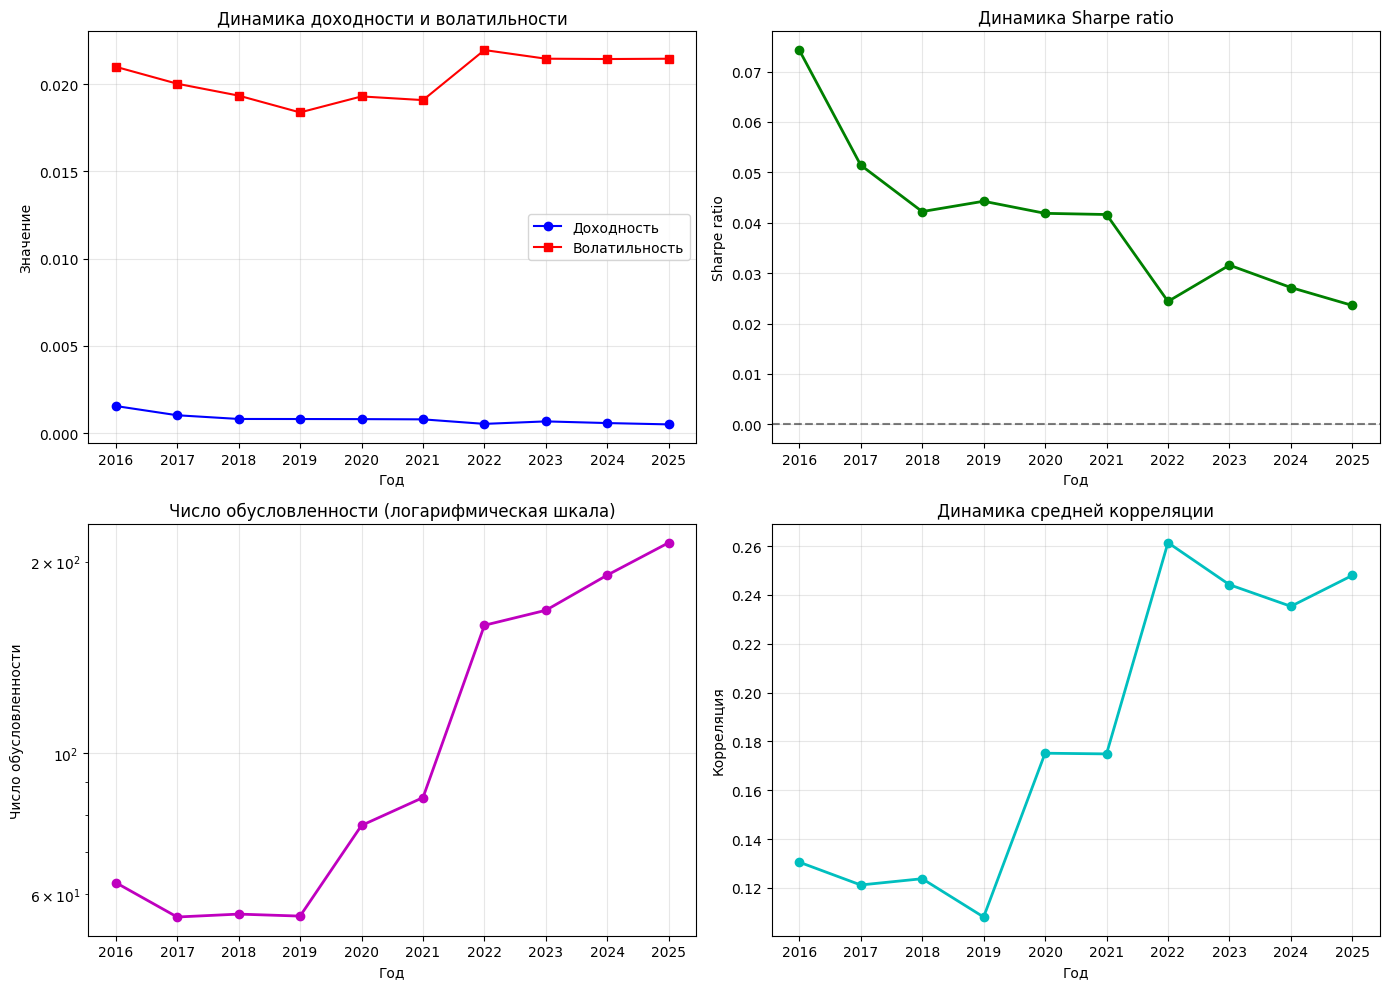

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
years = stats_df['date'].dt.year

axes[0, 0].plot(years, stats_df['avg_return'], 'b-', marker='o', label='Доходность')
axes[0, 0].plot(years, stats_df['avg_volatility'], 'r-', marker='s', label='Волатильность')
axes[0, 0].set_title('Динамика доходности и волатильности')
axes[0, 0].set_xlabel('Год')
axes[0, 0].set_ylabel('Значение')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(years)

axes[0, 1].plot(years, stats_df['sharpe_ratio'], 'g-', marker='o', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Динамика Sharpe ratio')
axes[0, 1].set_xlabel('Год')
axes[0, 1].set_ylabel('Sharpe ratio')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(years)

axes[1, 0].semilogy(years, stats_df['condition_number'], 'm-', marker='o', linewidth=2)
axes[1, 0].set_title('Число обусловленности (логарифмическая шкала)')
axes[1, 0].set_xlabel('Год')
axes[1, 0].set_ylabel('Число обусловленности')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(years)

axes[1, 1].plot(years, stats_df['avg_correlation'], 'c-', marker='o', linewidth=2)
axes[1, 1].set_title('Динамика средней корреляции')
axes[1, 1].set_xlabel('Год')
axes[1, 1].set_ylabel('Корреляция')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(years)

plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_1.png', bbox_inches='tight')
plt.show()


- Наилучшая диверсификация достигнута в 2019 году

- Число обусловленности наименьшее в 2019 году

- Самый низкий риск зафиксирован в 2019 году. Для создания чистых условий эксперимента предпочтителен спокойный рынок с минимальными случайными колебаниями.

- 2019 год представляет собой компромиссный вариант: ближе к современности, чем 2016-2017, но сохраняет стабильные характеристики докризисного периода.


Итоговый выбор для расчёта границы эффективных портфелей для различных ограничений: **годовое расширяющееся окно с равными весами за 2019 год**.

# 5. Построить на выбранном в п. 4 историческом окне границу эффективных портфелей при условии, что короткие продажи разрешены и не имеют ограничений.

In [22]:
# Доходности для расширяющегося окна с равными весами
mu = pd.read_excel("results.xlsx", sheet_name="mu_expand_y", index_col=0)

# Ковариационная матрица на 31.12.2019
cov = pd.read_excel("results.xlsx", sheet_name="cov_exp_20191231", index_col=0)

# Берем данные на 2019 год
date = pd.Timestamp('2019-12-31')
mu_2019 = mu.loc[date].values
cov_2019 = cov.values

n_assets = len(mu_2019)
min_return = mu_2019.min()
max_return = mu_2019.max()

print(f"Количество акций: {n_assets}")
print(f"Средняя доходность: {mu_2019.mean():.6f}")
print(f"Диапазон доходностей: {min_return:.6f} - {max_return:.6f}")

Количество акций: 30
Средняя доходность: 0.000814
Диапазон доходностей: -0.000667 - 0.001755


In [23]:
# Функция расчета доходности портфеля
def portfolio_return(weights, mu):
    return np.sum(weights * mu)

# Функция расчета волатильности портфеля
def portfolio_volatility(weights, cov):
    return np.sqrt(weights @ cov @ weights)

# Функция расчета Sharpe ratio
def portfolio_sharpe(weights, mu, cov):
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    return ret / vol if vol > 0 else 0

In [24]:
# Начальное приближение: равные веса
x0 = np.ones(n_assets) / n_assets

# Ограничение: сумма весов = 1
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

# Целевая функция: минимизация волатильности
def min_vol_objective(w):
    return portfolio_volatility(w, cov_2019)

# Оптимизация
result_min_vol = minimize(min_vol_objective, x0, constraints=constraints)

weights_min_vol = result_min_vol.x
ret_min_vol = portfolio_return(weights_min_vol, mu_2019)
vol_min_vol = portfolio_volatility(weights_min_vol, cov_2019)

print(f"Портфель с минимальной волатильностью:")
print(f"Доходность: {ret_min_vol:.6f}")
print(f"Волатильность: {vol_min_vol:.6f}")

Портфель с минимальной волатильностью:
Доходность: 0.000691
Волатильность: 0.006434


In [25]:
# Максимизация Sharpe ratio
def max_sharpe_objective(w):
    return -portfolio_sharpe(w, mu_2019, cov_2019)

result_max_sharpe = minimize(
    max_sharpe_objective,
    x0,
    constraints=constraints,
    options={'maxiter': 1000}
)

weights_max_sharpe = result_max_sharpe.x
ret_max_sharpe = portfolio_return(weights_max_sharpe, mu_2019)
vol_max_sharpe = portfolio_volatility(weights_max_sharpe, cov_2019)
sharpe_max = portfolio_sharpe(weights_max_sharpe, mu_2019, cov_2019)

print(f"Портфель с максимальным Sharpe ratio:")
print(f"Доходность: {ret_max_sharpe:.6f}")
print(f"Волатильность: {vol_max_sharpe:.6f}")
print(f"Sharpe ratio: {sharpe_max:.6f}")

Портфель с максимальным Sharpe ratio:
Доходность: 0.002333
Волатильность: 0.011737
Sharpe ratio: 0.198739


In [26]:
# Целевые доходности
target_returns = np.linspace(min_return, max_return, 50)

efficient_portfolios = []

for target in target_returns:
    constraints_target = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mu_2019) - target}
    ]

    result = minimize(
        min_vol_objective,
        x0,
        constraints=constraints_target,
        options={'maxiter': 1000}
    )

    if result.success:
        w = result.x
        ret = portfolio_return(w, mu_2019)
        vol = portfolio_volatility(w, cov_2019)
        efficient_portfolios.append({
            'return': ret,
            'volatility': vol,
            'sharpe': ret / vol if vol > 0 else 0
        })

df_portfolios = pd.DataFrame(efficient_portfolios)

print(f"{len(df_portfolios)} эффективных портфелей")
print(f"Диапазон доходностей: {df_portfolios['return'].min():.6f} - {df_portfolios['return'].max():.6f}")
print(f"Диапазон волатильности: {df_portfolios['volatility'].min():.6f} - {df_portfolios['volatility'].max():.6f}")

50 эффективных портфелей
Диапазон доходностей: -0.000667 - 0.001755
Диапазон волатильности: 0.006434 - 0.010445


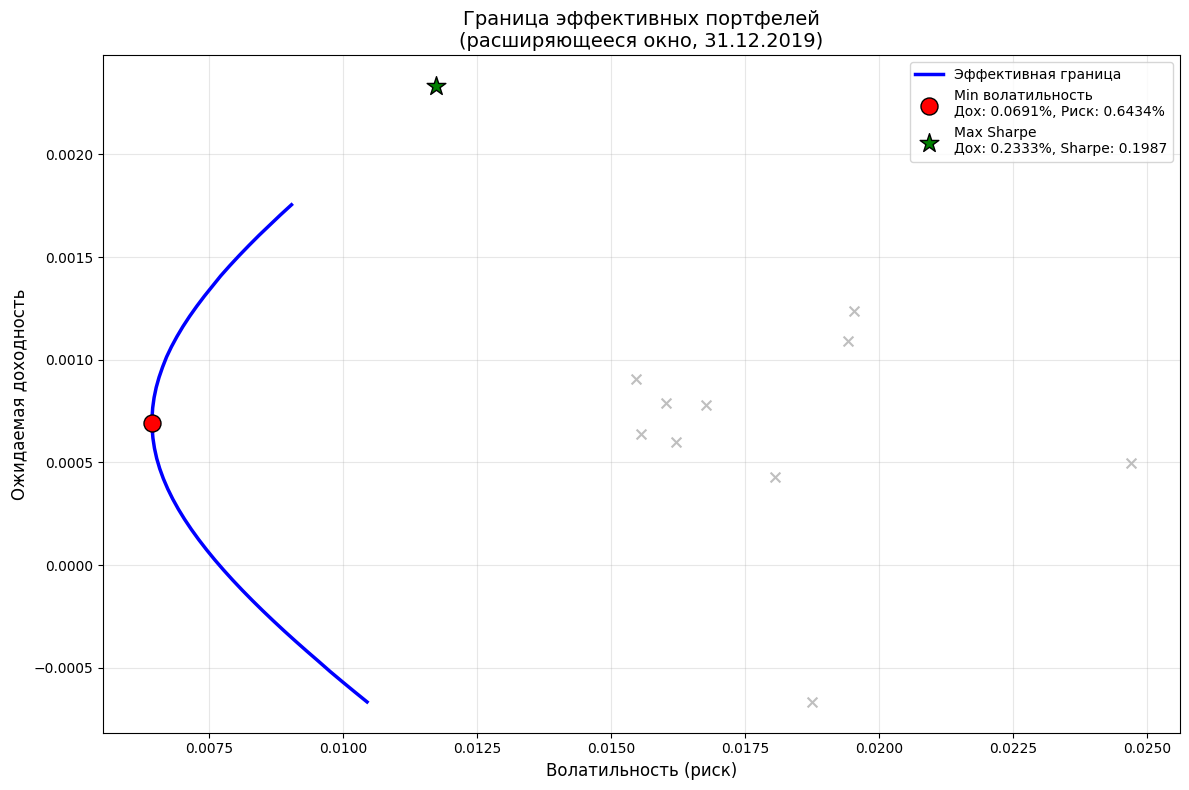

In [27]:
plt.figure(figsize=(12, 8))

# Граница эффективных портфелей
plt.plot(df_portfolios['volatility'], df_portfolios['return'],
         'b-', linewidth=2.5, label='Эффективная граница')

# Портфель с минимальной волатильностью
plt.scatter(vol_min_vol, ret_min_vol,
            color='red', s=150, marker='o',
            label=f'Min волатильность\nДох: {ret_min_vol*100:.4f}%, Риск: {vol_min_vol*100:.4f}%',
            zorder=5, edgecolors='black')

# Портфель с максимальным Sharpe
if 'ret_max_sharpe' in locals():
    plt.scatter(vol_max_sharpe, ret_max_sharpe,
                color='green', s=200, marker='*',
                label=f'Max Sharpe\nДох: {ret_max_sharpe*100:.4f}%, Sharpe: {sharpe_max:.4f}',
                zorder=5, edgecolors='black')

# Отдельные акции (для сравнения)
for i in range(min(10, n_assets)):
    vol_i = np.sqrt(cov_2019[i, i])
    ret_i = mu_2019[i]
    plt.scatter(vol_i, ret_i, color='gray', s=50, marker='x', alpha=0.5)

plt.xlabel('Волатильность (риск)', fontsize=12)
plt.ylabel('Ожидаемая доходность', fontsize=12)
plt.title('Граница эффективных портфелей\n(расширяющееся окно, 31.12.2019)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_2.png', bbox_inches='tight')
plt.show()

- Максимальный Sharpe ratio составляет 0.1987, что достигается при доходности 0.2333% и волатильности 1.1737%

- Портфель с минимальным риском имеет волатильность 0.6434% при доходности 0.0691%

# 6. Построить на выбранном в п. 4 историческом окне границу эффективных портфелей при условии, что короткие продажи разрешены, но доходы от короткой продажи каждой акции не должны превышать 25% от собственных средств (капитала) инвестора

In [28]:
def short_constraint(weights):
    # Сумма коротких позиций должна быть >= -0.25
    short_sum = -np.sum(weights[weights < 0])
    return 0.25 - short_sum

In [29]:
# Ограничения: сумма весов = 1, короткие позиции ≤ 25%
constraints_min_vol = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {'type': 'ineq', 'fun': short_constraint}
]

result_min_vol_lim = minimize(
    min_vol_objective,
    x0,
    constraints=constraints_min_vol,
    options={'maxiter': 1000}
)

weights_min_vol_lim = result_min_vol_lim.x
ret_min_vol_lim = portfolio_return(weights_min_vol_lim, mu_2019)
vol_min_vol_lim = portfolio_volatility(weights_min_vol_lim, cov_2019)

print(f"Портфель с минимальной волатильностью:")
print(f"Доходность: {ret_min_vol_lim:.6f}")
print(f"Волатильность: {vol_min_vol_lim:.6f}")
print(f"Sharpe ratio: {ret_min_vol_lim/vol_min_vol_lim:.4f}")

short_sum = -np.sum(weights_min_vol_lim[weights_min_vol_lim < 0])
print(f"Сумма коротких позиций: {short_sum:.4f}")

Портфель с минимальной волатильностью:
Доходность: 0.000691
Волатильность: 0.006434
Sharpe ratio: 0.1073
Сумма коротких позиций: 0.1506


In [30]:
result_max_sharpe_lim = minimize(
    max_sharpe_objective,
    x0,
    constraints=constraints_min_vol,
    options={'maxiter': 1000}
)

weights_max_sharpe_lim = result_max_sharpe_lim.x
ret_max_sharpe_lim = portfolio_return(weights_max_sharpe_lim, mu_2019)
vol_max_sharpe_lim = portfolio_volatility(weights_max_sharpe_lim, cov_2019)
sharpe_max_lim = portfolio_sharpe(weights_max_sharpe_lim, mu_2019, cov_2019)

print(f"Портфель с максимальным Sharpe ratio")
print(f"Доходность: {ret_max_sharpe_lim:.6f}")
print(f"Волатильность: {vol_max_sharpe_lim:.6f}")
print(f"Sharpe ratio: {sharpe_max_lim:.4f}")

short_sum = np.sum(weights_max_sharpe_lim[weights_max_sharpe_lim < 0])
print(f"Сумма коротких позиций: {short_sum:.4f}")

Портфель с максимальным Sharpe ratio
Доходность: 0.001735
Волатильность: 0.009154
Sharpe ratio: 0.1896
Сумма коротких позиций: -0.2500


In [31]:
target_returns_lim = np.linspace(min_return, max_return, 50)

efficient_portfolios_lim = []

for target in target_returns_lim:
    constraints_target = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mu_2019) - target},
        {'type': 'ineq', 'fun': short_constraint}
    ]

    result = minimize(
        min_vol_objective,
        x0,
        constraints=constraints_target,
        options={'maxiter': 1000}
    )

    if result.success:
        w = result.x
        ret = portfolio_return(w, mu_2019)
        vol = portfolio_volatility(w, cov_2019)
        efficient_portfolios_lim.append({
            'return': ret,
            'volatility': vol,
            'sharpe': ret / vol if vol > 0 else 0
        })

df_portfolios_lim = pd.DataFrame(efficient_portfolios_lim)

print(f"Построено {len(df_portfolios_lim)} эффективных портфелей")
print(f"Диапазон доходностей: {df_portfolios_lim['return'].min():.6f} - {df_portfolios_lim['return'].max():.6f}")
print(f"Диапазон волатильности: {df_portfolios_lim['volatility'].min():.6f} - {df_portfolios_lim['volatility'].max():.6f}")

Построено 50 эффективных портфелей
Диапазон доходностей: -0.000667 - 0.001755
Диапазон волатильности: 0.006434 - 0.012216


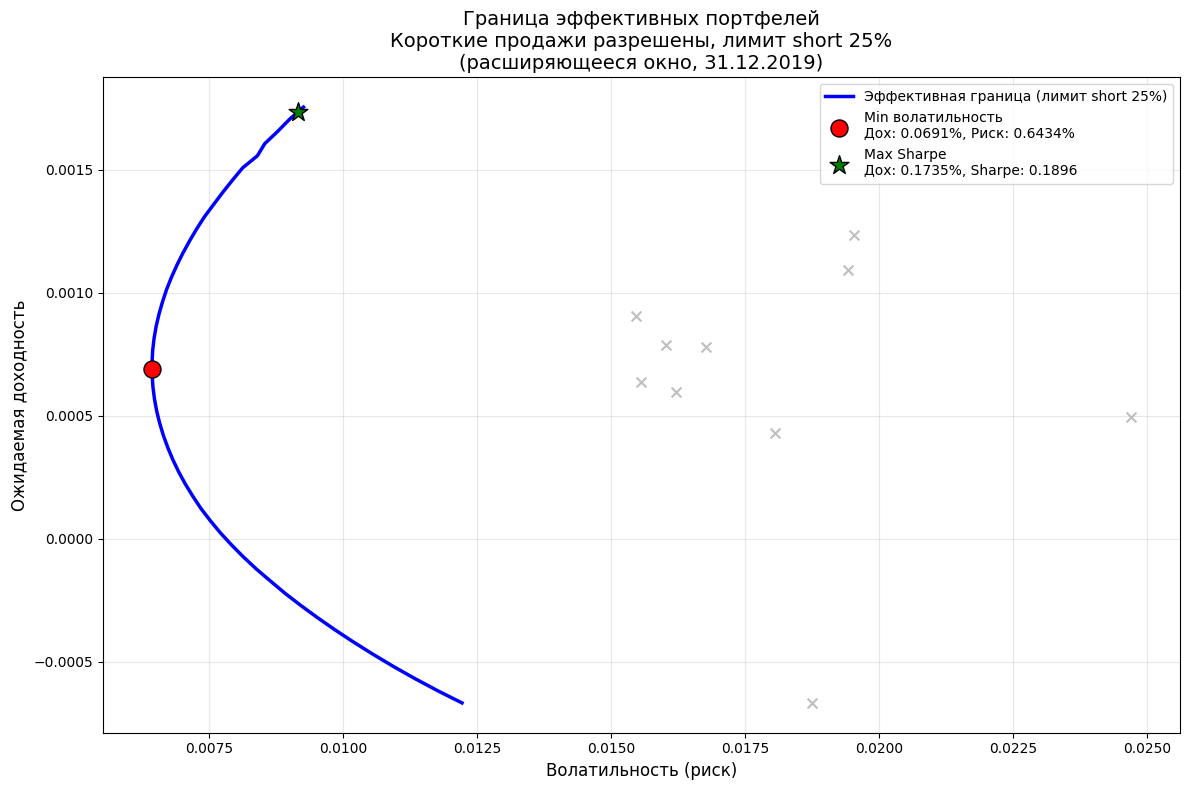

In [32]:
plt.figure(figsize=(12, 8))

# Граница эффективных портфелей
plt.plot(df_portfolios_lim['volatility'], df_portfolios_lim['return'],
         'b-', linewidth=2.5, label='Эффективная граница (лимит short 25%)')

# Портфель с минимальной волатильностью
plt.scatter(vol_min_vol_lim, ret_min_vol_lim,
            color='red', s=150, marker='o',
            label=f'Min волатильность\nДох: {ret_min_vol_lim*100:.4f}%, Риск: {vol_min_vol_lim*100:.4f}%',
            zorder=5, edgecolors='black')

# Портфель с максимальным Sharpe
plt.scatter(vol_max_sharpe_lim, ret_max_sharpe_lim,
            color='green', s=200, marker='*',
            label=f'Max Sharpe\nДох: {ret_max_sharpe_lim*100:.4f}%, Sharpe: {sharpe_max_lim:.4f}',
            zorder=5, edgecolors='black')

# Отдельные акции
for i in range(min(10, n_assets)):
    vol_i = np.sqrt(cov_2019[i, i])
    ret_i = mu_2019[i]
    plt.scatter(vol_i, ret_i, color='gray', s=50, marker='x', alpha=0.5)

plt.xlabel('Волатильность (риск)', fontsize=12)
plt.ylabel('Ожидаемая доходность', fontsize=12)
plt.title('Граница эффективных портфелей\nКороткие продажи разрешены, лимит short 25%\n(расширяющееся окно, 31.12.2019)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_3.png', bbox_inches='tight')
plt.show()

- Максимальный Sharpe ratio составляет 0.1896, что достигается при доходности 0.1735% и волатильности 0.9152%

- Портфель с минимальным риском имеет волатильность 0.6434% при доходности 0.0691%

# 7. Построить на выбранном в п. 4 историческом окне границу эффективных портфелей при условии, что короткие продажи запрещены.

In [33]:
# Запрет коротких продаж
bounds_no_short = [(0, 1) for _ in range(n_assets)]

# Ограничения: сумма весов = 1, веса ≥ 0
constraints_no_short = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
]

result_min_vol_no_short = minimize(
    min_vol_objective,
    x0,
    bounds=bounds_no_short,
    constraints=constraints_no_short,
    options={'maxiter': 1000}
)

weights_min_vol_no_short = result_min_vol_no_short.x
ret_min_vol_no_short = portfolio_return(weights_min_vol_no_short, mu_2019)
vol_min_vol_no_short = portfolio_volatility(weights_min_vol_no_short, cov_2019)

print(f"Портфель с минимальной волатильностью (без short):")
print(f"Доходность: {ret_min_vol_no_short:.6f} ({ret_min_vol_no_short*100:.4f}%)")
print(f"Волатильность: {vol_min_vol_no_short:.6f} ({vol_min_vol_no_short*100:.4f}%)")
print(f"Sharpe ratio: {ret_min_vol_no_short/vol_min_vol_no_short:.4f}")
print(f"Количество активных позиций: {(weights_min_vol_no_short > 0.001).sum()}")

Портфель с минимальной волатильностью (без short):
Доходность: 0.000759 (0.0759%)
Волатильность: 0.006594 (0.6594%)
Sharpe ratio: 0.1151
Количество активных позиций: 19


In [34]:
result_max_sharpe_no_short = minimize(
    max_sharpe_objective,
    x0,
    bounds=bounds_no_short,
    constraints=constraints_no_short,
    options={'maxiter': 1000}
)

weights_max_sharpe_no_short = result_max_sharpe_no_short.x
ret_max_sharpe_no_short = portfolio_return(weights_max_sharpe_no_short, mu_2019)
vol_max_sharpe_no_short = portfolio_volatility(weights_max_sharpe_no_short, cov_2019)
sharpe_max_no_short = portfolio_sharpe(weights_max_sharpe_no_short, mu_2019, cov_2019)

print(f"Портфель с максимальным Sharpe ratio (без short):")
print(f"Доходность: {ret_max_sharpe_no_short:.6f}")
print(f"Волатильность: {vol_max_sharpe_no_short:.6f}")
print(f"Sharpe ratio: {sharpe_max_no_short:.4f}")
print(f"Количество активных позиций: {(weights_max_sharpe_no_short > 0.001).sum()}")

Портфель с максимальным Sharpe ratio (без short):
Доходность: 0.001349
Волатильность: 0.008202
Sharpe ratio: 0.1645
Количество активных позиций: 10


In [35]:
target_returns_no_short = np.linspace(min_return, max_return, 50)

efficient_portfolios_no_short = []

for target in target_returns_no_short:
    constraints_target = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mu_2019) - target}
    ]

    result = minimize(
        min_vol_objective,
        x0,
        bounds=bounds_no_short,
        constraints=constraints_target,
        options={'maxiter': 1000}
    )

    if result.success:
        w = result.x
        ret = portfolio_return(w, mu_2019)
        vol = portfolio_volatility(w, cov_2019)
        efficient_portfolios_no_short.append({
            'return': ret,
            'volatility': vol,
            'sharpe': ret / vol if vol > 0 else 0
        })

df_portfolios_no_short = pd.DataFrame(efficient_portfolios_no_short)

print(f"Построено {len(df_portfolios_no_short)} эффективных портфелей")
print(f"Диапазон доходностей: {df_portfolios_no_short['return'].min():.6f} - {df_portfolios_no_short['return'].max():.6f}")
print(f"Диапазон волатильности: {df_portfolios_no_short['volatility'].min():.6f} - {df_portfolios_no_short['volatility'].max():.6f}")

Построено 50 эффективных портфелей
Диапазон доходностей: -0.000667 - 0.001755
Диапазон волатильности: 0.006596 - 0.019611


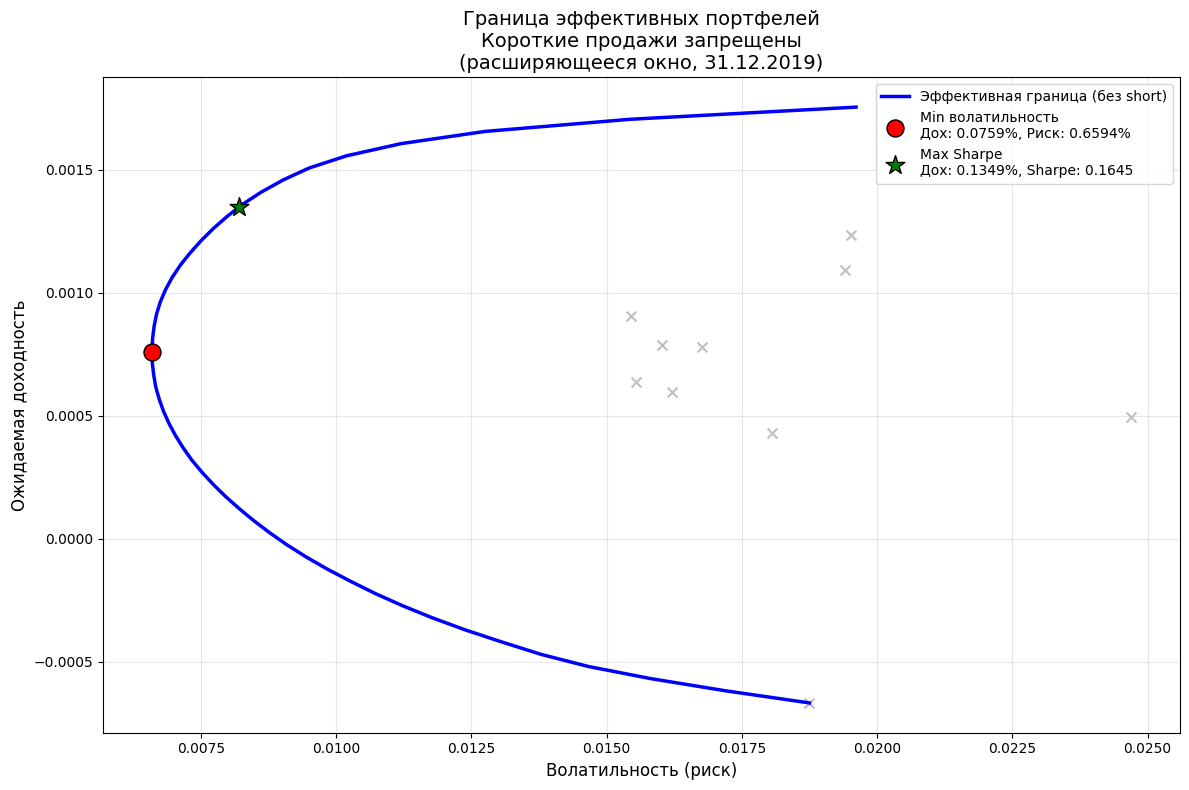

In [36]:
plt.figure(figsize=(12, 8))

# Граница эффективных портфелей (без short)
plt.plot(df_portfolios_no_short['volatility'], df_portfolios_no_short['return'],
         'b-', linewidth=2.5, label='Эффективная граница (без short)')

# Портфель с минимальной волатильностью
plt.scatter(vol_min_vol_no_short, ret_min_vol_no_short,
            color='red', s=150, marker='o',
            label=f'Min волатильность\nДох: {ret_min_vol_no_short*100:.4f}%, Риск: {vol_min_vol_no_short*100:.4f}%',
            zorder=5, edgecolors='black')

# Портфель с максимальным Sharpe
plt.scatter(vol_max_sharpe_no_short, ret_max_sharpe_no_short,
            color='green', s=200, marker='*',
            label=f'Max Sharpe\nДох: {ret_max_sharpe_no_short*100:.4f}%, Sharpe: {sharpe_max_no_short:.4f}',
            zorder=5, edgecolors='black')

# Отдельные акции
for i in range(min(10, n_assets)):
    vol_i = np.sqrt(cov_2019[i, i])
    ret_i = mu_2019[i]
    plt.scatter(vol_i, ret_i, color='gray', s=50, marker='x', alpha=0.5)

plt.xlabel('Волатильность (риск)', fontsize=12)
plt.ylabel('Ожидаемая доходность', fontsize=12)
plt.title('Граница эффективных портфелей\nКороткие продажи запрещены\n(расширяющееся окно, 31.12.2019)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_4.png', bbox_inches='tight')
plt.show()

- Максимальный Sharpe ratio составляет 0.1645, что достигается при доходности 0.1349% и волатильности 0.8202% и 10 активных позициях

- Портфель с минимальным риском имеет волатильность 0.6594% при доходности 0.0759% и включает 19 активных позиций

# 8. Построить на выбранном в п. 4 историческом окне границу эффективных портфелей при условии, что в каждую из акций должно быть вложено не менее 2% капитала.

In [37]:
# Минимум 2% в каждую акцию
bounds_min_2pct = [(0.02, 1) for _ in range(n_assets)]

print(f"Минимальная сумма весов при 2% в каждую акцию: {n_assets * 0.02:.2f}")

Минимальная сумма весов при 2% в каждую акцию: 0.60


In [38]:
constraints_min_2pct = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
]

result_min_vol_min_2pct = minimize(
    min_vol_objective,
    x0,
    bounds=bounds_min_2pct,
    constraints=constraints_min_2pct,
    options={'maxiter': 1000}
)

weights_min_vol_min_2pct = result_min_vol_min_2pct.x
ret_min_vol_min_2pct = portfolio_return(weights_min_vol_min_2pct, mu_2019)
vol_min_vol_min_2pct = portfolio_volatility(weights_min_vol_min_2pct, cov_2019)

print(f"Портфель с минимальной волатильностью (min 2%):")
print(f"Доходность: {ret_min_vol_min_2pct:.6f}")
print(f"Волатильность: {vol_min_vol_min_2pct:.6f}")
print(f"Sharpe ratio: {ret_min_vol_min_2pct/vol_min_vol_min_2pct:.4f}")
print(f"Минимальный вес: {weights_min_vol_min_2pct.min():.4f}")
print(f"Максимальный вес: {weights_min_vol_min_2pct.max():.4f}")

Портфель с минимальной волатильностью (min 2%):
Доходность: 0.000827
Волатильность: 0.007104
Sharpe ratio: 0.1164
Минимальный вес: 0.0200
Максимальный вес: 0.1230


In [39]:
result_max_sharpe_min_2pct = minimize(
    max_sharpe_objective,
    x0,
    bounds=bounds_min_2pct,
    constraints=constraints_min_2pct,
    options={'maxiter': 1000}
)

weights_max_sharpe_min_2pct = result_max_sharpe_min_2pct.x
ret_max_sharpe_min_2pct = portfolio_return(weights_max_sharpe_min_2pct, mu_2019)
vol_max_sharpe_min_2pct = portfolio_volatility(weights_max_sharpe_min_2pct, cov_2019)
sharpe_max_min_2pct = portfolio_sharpe(weights_max_sharpe_min_2pct, mu_2019, cov_2019)

print(f"Портфель с максимальным Sharpe ratio (min 2%):")
print(f"Доходность: {ret_max_sharpe_min_2pct:.6f}")
print(f"Волатильность: {vol_max_sharpe_min_2pct:.6f}")
print(f"Sharpe ratio: {sharpe_max_min_2pct:.4f}")
print(f"Минимальный вес: {weights_max_sharpe_min_2pct.min():.4f}")
print(f"Максимальный вес: {weights_max_sharpe_min_2pct.max():.4f}")

Портфель с максимальным Sharpe ratio (min 2%):
Доходность: 0.001093
Волатильность: 0.007903
Sharpe ratio: 0.1382
Минимальный вес: 0.0200
Максимальный вес: 0.1819


In [40]:
target_returns_min_2pct = np.linspace(min_return, max_return, 50)

efficient_portfolios_min_2pct = []

for target in target_returns_min_2pct:
    constraints_target = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mu_2019) - target}
    ]

    result = minimize(
        min_vol_objective,
        x0,
        bounds=bounds_min_2pct,
        constraints=constraints_target,
        options={'maxiter': 1000}
    )

    if result.success:
        w = result.x
        ret = portfolio_return(w, mu_2019)
        vol = portfolio_volatility(w, cov_2019)
        efficient_portfolios_min_2pct.append({
            'return': ret,
            'volatility': vol,
            'sharpe': ret / vol if vol > 0 else 0
        })

df_portfolios_min_2pct = pd.DataFrame(efficient_portfolios_min_2pct)

print(f"Построено {len(df_portfolios_min_2pct)} эффективных портфелей")
print(f"Диапазон доходностей: {df_portfolios_min_2pct['return'].min():.6f} - {df_portfolios_min_2pct['return'].max():.6f}")
print(f"Диапазон волатильности: {df_portfolios_min_2pct['volatility'].min():.6f} - {df_portfolios_min_2pct['volatility'].max():.6f}")

Построено 20 эффективных портфелей
Диапазон доходностей: 0.000223 - 0.001162
Диапазон волатильности: 0.007108 - 0.010553


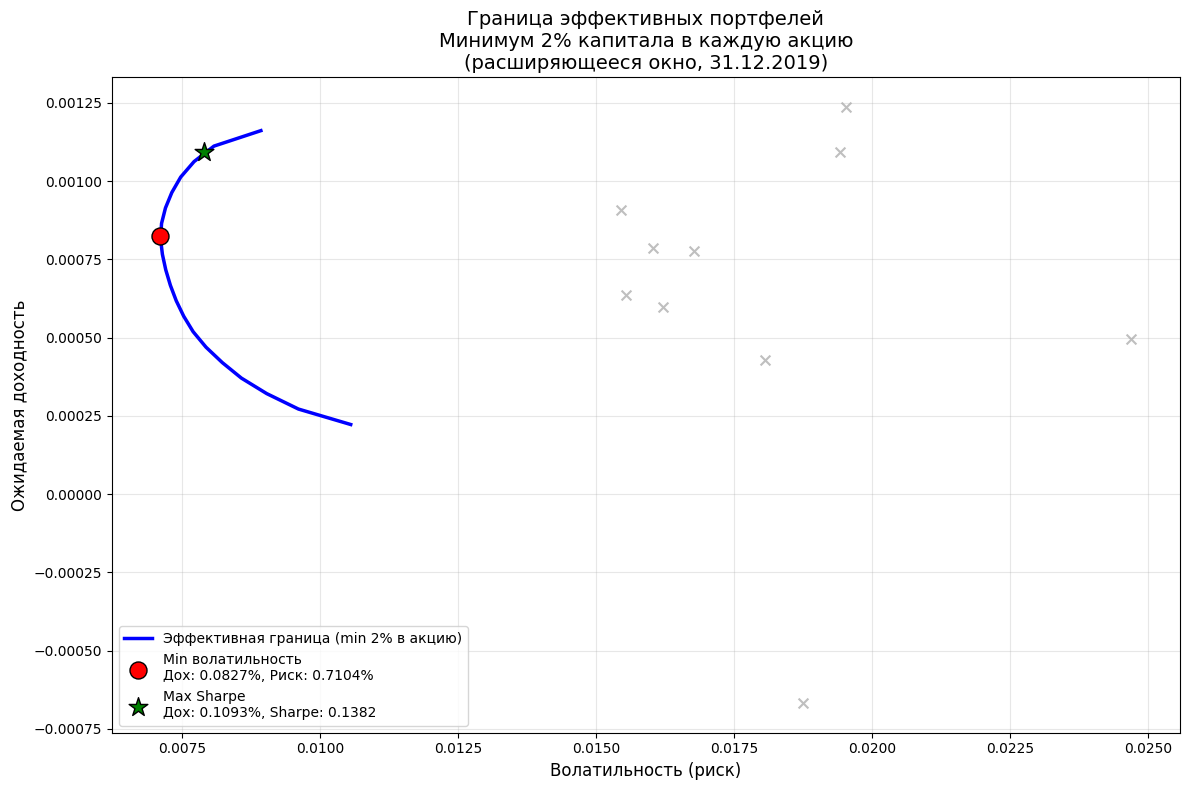

In [41]:
plt.figure(figsize=(12, 8))

# Граница эффективных портфелей (min 2%)
plt.plot(df_portfolios_min_2pct['volatility'], df_portfolios_min_2pct['return'],
         'b-', linewidth=2.5, label='Эффективная граница (min 2% в акцию)')

# Портфель с минимальной волатильностью
plt.scatter(vol_min_vol_min_2pct, ret_min_vol_min_2pct,
            color='red', s=150, marker='o',
            label=f'Min волатильность\nДох: {ret_min_vol_min_2pct*100:.4f}%, Риск: {vol_min_vol_min_2pct*100:.4f}%',
            zorder=5, edgecolors='black')

# Портфель с максимальным Sharpe
plt.scatter(vol_max_sharpe_min_2pct, ret_max_sharpe_min_2pct,
            color='green', s=200, marker='*',
            label=f'Max Sharpe\nДох: {ret_max_sharpe_min_2pct*100:.4f}%, Sharpe: {sharpe_max_min_2pct:.4f}',
            zorder=5, edgecolors='black')

# Отдельные акции
for i in range(min(10, n_assets)):
    vol_i = np.sqrt(cov_2019[i, i])
    ret_i = mu_2019[i]
    plt.scatter(vol_i, ret_i, color='gray', s=50, marker='x', alpha=0.5)

plt.xlabel('Волатильность (риск)', fontsize=12)
plt.ylabel('Ожидаемая доходность', fontsize=12)
plt.title('Граница эффективных портфелей\nМинимум 2% капитала в каждую акцию\n(расширяющееся окно, 31.12.2019)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_5.png', bbox_inches='tight')
plt.show()

- Максимальный Sharpe ratio составляет 0.1382, что достигается при доходности 0.1093% и волатильности 0.7903%

- Портфель с минимальным риском имеет волатильность 0.7104% при доходности 0.0827% и Sharpe ratio 0.1164

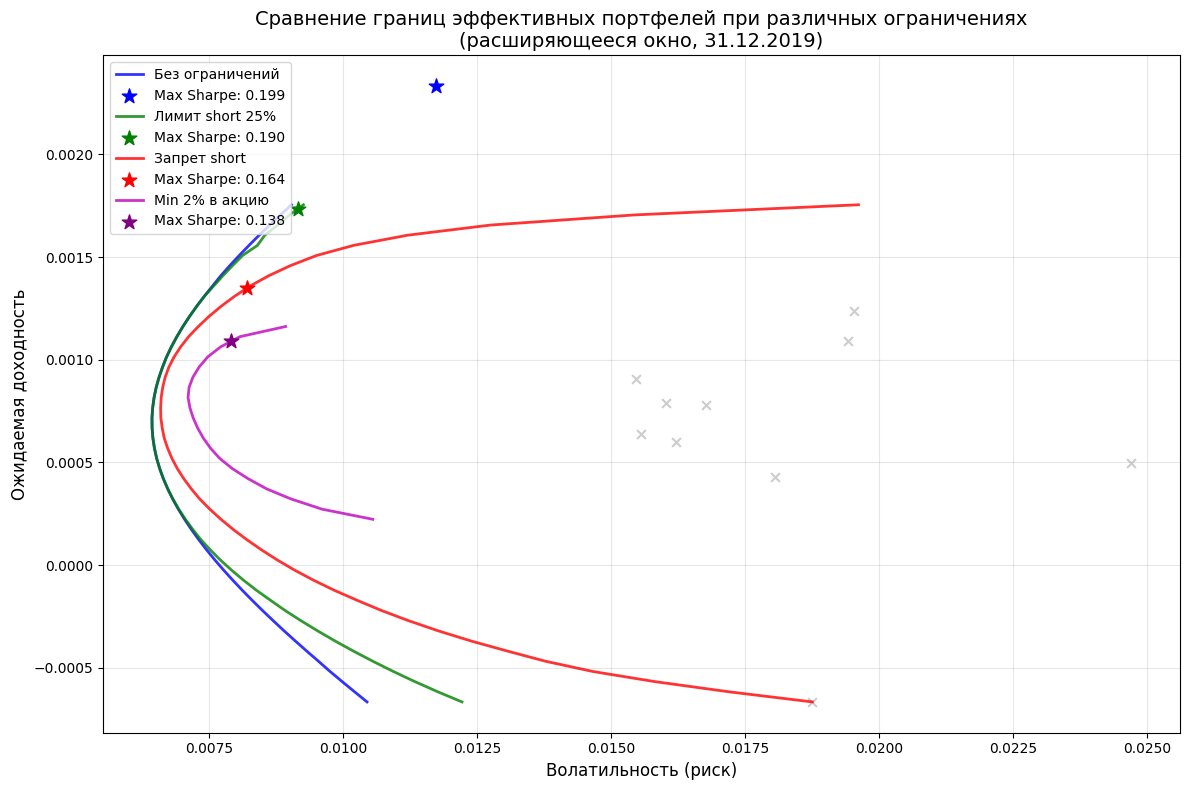

In [42]:
plt.figure(figsize=(12, 8))

plt.plot(df_portfolios['volatility'], df_portfolios['return'],
         'b-', linewidth=2, label='Без ограничений', alpha=0.8)
plt.scatter(vol_max_sharpe, ret_max_sharpe,
            color='blue', s=120, marker='*',
            label=f'Max Sharpe: {sharpe_max:.3f}', zorder=5)

plt.plot(df_portfolios_lim['volatility'], df_portfolios_lim['return'],
         'g-', linewidth=2, label='Лимит short 25%', alpha=0.8)
plt.scatter(vol_max_sharpe_lim, ret_max_sharpe_lim,
            color='green', s=120, marker='*',
            label=f'Max Sharpe: {sharpe_max_lim:.3f}', zorder=5)

plt.plot(df_portfolios_no_short['volatility'], df_portfolios_no_short['return'],
         'r-', linewidth=2, label='Запрет short', alpha=0.8)
plt.scatter(vol_max_sharpe_no_short, ret_max_sharpe_no_short,
            color='red', s=120, marker='*',
            label=f'Max Sharpe: {sharpe_max_no_short:.3f}', zorder=5)

plt.plot(df_portfolios_min_2pct['volatility'], df_portfolios_min_2pct['return'],
         'm-', linewidth=2, label='Min 2% в акцию', alpha=0.8)
plt.scatter(vol_max_sharpe_min_2pct, ret_max_sharpe_min_2pct,
            color='purple', s=120, marker='*',
            label=f'Max Sharpe: {sharpe_max_min_2pct:.3f}', zorder=5)

for i in range(min(10, n_assets)):
    vol_i = np.sqrt(cov_2019[i, i])
    ret_i = mu_2019[i]
    plt.scatter(vol_i, ret_i, color='gray', s=40, marker='x', alpha=0.4)

plt.xlabel('Волатильность (риск)', fontsize=12)
plt.ylabel('Ожидаемая доходность', fontsize=12)
plt.title('Сравнение границ эффективных портфелей при различных ограничениях\n(расширяющееся окно, 31.12.2019)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_6.png', bbox_inches='tight')
plt.show()

In [43]:
print(f"{'Показатель':<30} {'Без огр':<18} {'Лимит 25%':<18} {'Без short':<18} {'Min 2%':<18}")
print("-"*105)

print(f"{'Max Sharpe ratio':<30} {sharpe_max:<18.4f} {sharpe_max_lim:<18.4f} {sharpe_max_no_short:<18.4f} {sharpe_max_min_2pct:<18.4f}")
print(f"{'Доходность, %':<30} {ret_max_sharpe*100:<18.4f} {ret_max_sharpe_lim*100:<18.4f} {ret_max_sharpe_no_short*100:<18.4f} {ret_max_sharpe_min_2pct*100:<18.4f}")
print(f"{'Волатильность, %':<30} {vol_max_sharpe*100:<18.4f} {vol_max_sharpe_lim*100:<18.4f} {vol_max_sharpe_no_short*100:<18.4f} {vol_max_sharpe_min_2pct*100:<18.4f}")

Показатель                     Без огр            Лимит 25%          Без short          Min 2%            
---------------------------------------------------------------------------------------------------------
Max Sharpe ratio               0.1987             0.1896             0.1645             0.1382            
Доходность, %                  0.2333             0.1735             0.1349             0.1093            
Волатильность, %               1.1737             0.9154             0.8202             0.7903            


Наиболее эффективным с точки зрения соотношения риск/доходность является портфель без ограничений на короткие продажи. Введение любого ограничения приводит к ухудшению характеристик портфеля:

- Лимит short 25% — умеренное снижение эффективности (-5%) при сохранении возможности использования коротких продаж

- Запрет short — значительное снижение эффективности (-17%) и концентрация портфеля в 10 акциях

- Min 2% в акцию — максимальное снижение эффективности (-30%) при принудительной диверсификации на все 30 акций

#13.	Рассчитать на выбранном в п. 12 историческом окне для отобранных акций ковариационную матрицу на основе исторических β (historical betas), которые оцениваются согласно рыночной модели (market model).

In [44]:
date = pd.Timestamp('2019-12-31')

# Доходности акций на выбранную дату
mu_2019 = mu_expand.loc[date].values
# Историческая ковариационная матрица на выбранную дату
cov_2019 = covs_expand[date].values
# Доходности акций за всю историю для расчета бета (возьмем все доступные данные до 2019 года)
returns_historical = returns.loc[:date]

# 2. Расчет рыночного портфеля (равные веса)
n_assets = len(mu_2019)
market_weights = np.ones(n_assets) / n_assets
market_returns = returns_historical @ market_weights  # Доходность равновзвешенного портфеля

# 3. Расчет исторических бета для каждой акции
betas = {}
residuals_variance = {}

for i, ticker in enumerate(returns_historical.columns):
    # Регрессия доходности акции на доходность рыночного портфеля
    # Model: R_i = alpha + beta * R_m + epsilon
    X = sm.add_constant(market_returns)  # Добавляем константу для intercept
    model = sm.OLS(returns_historical[ticker], X).fit()
    # Бета - это коэффициент при рыночной доходности (второй параметр, индекс 1)
    betas[ticker] = model.params.iloc[1]
    residuals = model.resid
    residuals_variance[ticker] = residuals.var()

beta_vector = pd.Series(betas).values
residuals_variance_vector = pd.Series(residuals_variance).values

# 4. Расчет ковариационной матрицы на основе исторических бет
# Var(R_i) = beta_i^2 * Var(R_m) + Var(epsilon_i)
# Cov(R_i, R_j) = beta_i * beta_j * Var(R_m)

# Оценка рыночной дисперсии
var_market = market_returns.var()

# Построение ковариационной матрицы
cov_betas = np.zeros((n_assets, n_assets))
for i in range(n_assets):
    for j in range(n_assets):
        if i == j:
            # Дисперсия: beta_i^2 * Var(R_m) + Var(epsilon_i)
            cov_betas[i, j] = (beta_vector[i]**2) * var_market + residuals_variance_vector[i]
        else:
            # Ковариация: beta_i * beta_j * Var(R_m)
            cov_betas[i, j] = beta_vector[i] * beta_vector[j] * var_market

cov_betas_df = pd.DataFrame(cov_betas, index=returns_historical.columns, columns=returns_historical.columns)

print("Ковариационная матрица на основе исторических β (первые 5x5):")
print(cov_betas_df.iloc[:5, :5])

# Вывод статистики по бета-коэффициентам
print("\nСтатистика по историческим β-коэффициентам:")
print(f"Среднее значение β: {beta_vector.mean():.4f}")
print(f"Медиана β: {np.median(beta_vector):.4f}")
print(f"Минимальное значение β: {beta_vector.min():.4f}")
print(f"Максимальное значение β: {beta_vector.max():.4f}")
print(f"Стандартное отклонение β: {beta_vector.std():.4f}")

Ковариационная матрица на основе исторических β (первые 5x5):
          AFKS      AFLT      ALRS      BSPB      CHMF
AFKS  0.000610  0.000072  0.000081  0.000066  0.000074
AFLT  0.000072  0.000377  0.000055  0.000045  0.000050
ALRS  0.000081  0.000055  0.000326  0.000050  0.000056
BSPB  0.000066  0.000045  0.000050  0.000257  0.000046
CHMF  0.000074  0.000050  0.000056  0.000046  0.000263

Статистика по историческим β-коэффициентам:
Среднее значение β: 1.0000
Медиана β: 0.9765
Минимальное значение β: 0.4305
Максимальное значение β: 1.7467
Стандартное отклонение β: 0.3093


# 14.	Построить границу эффективных портфелей на основе полученной в п. 13 ковариационной матрицы.



Построено 50 эффективных портфелей (на основе исторических β)
Диапазон доходностей: -0.000667 - 0.001755
Диапазон волатильности: 0.006734 - 0.010245

Портфель с максимальным Sharpe ratio (на основе исторических β):
Доходность: 0.001755 (0.1755%)
Волатильность: 0.009419 (0.9419%)
Sharpe ratio: 0.1863


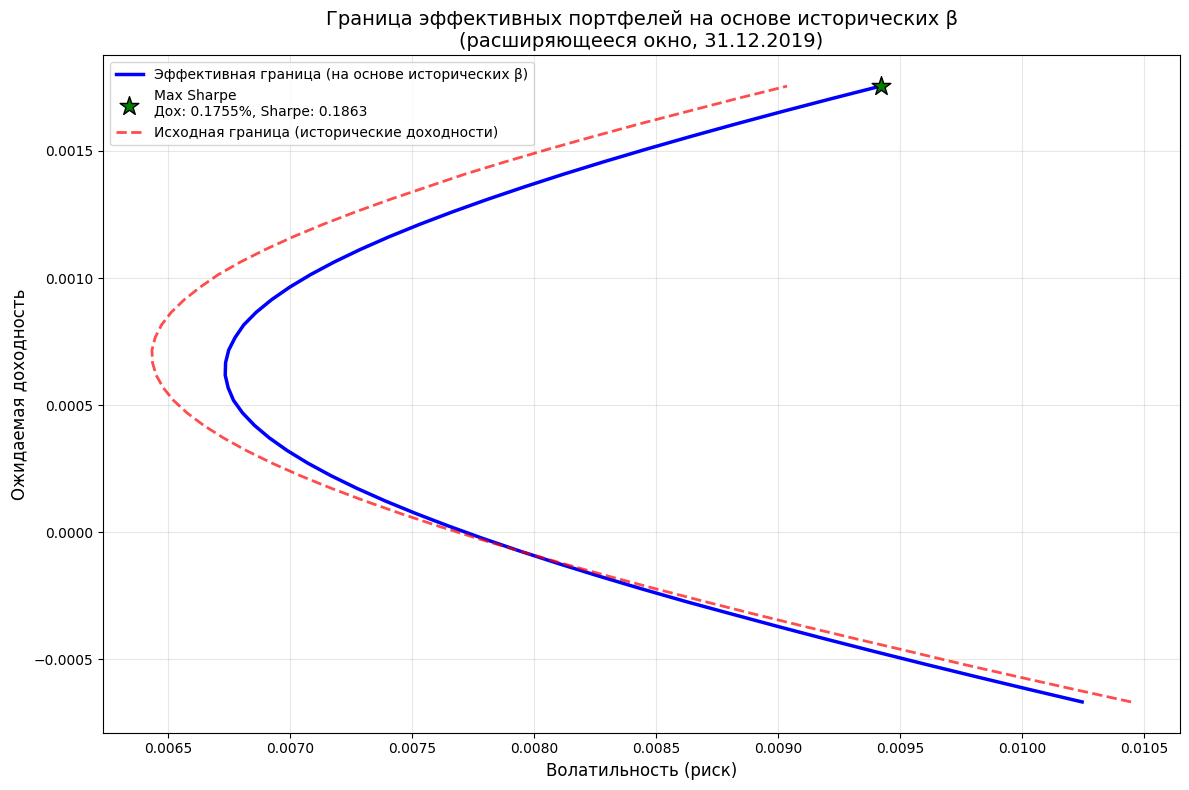

In [45]:
# Используем те же функции для расчета доходности и волатильности, что и ранее
def portfolio_return(weights, mu):
    return np.sum(weights * mu)

def portfolio_volatility(weights, cov):
    return np.sqrt(weights @ cov @ weights)

def portfolio_sharpe(weights, mu, cov):
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    return ret / vol if vol > 0 else 0

def min_vol_objective(w, cov):
    return portfolio_volatility(w, cov)

# Построение границы
target_returns_betas = np.linspace(mu_2019.min(), mu_2019.max(), 50)
efficient_portfolios_betas = []
x0 = np.ones(n_assets) / n_assets

for target in target_returns_betas:
    constraints_target = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mu_2019) - target}
    ]

    # Оптимизация с использованием ковариационной матрицы на основе бет
    result = minimize(
        min_vol_objective,
        x0,
        args=(cov_betas,),
        constraints=constraints_target,
        options={'maxiter': 1000}
    )

    if result.success:
        w = result.x
        ret = portfolio_return(w, mu_2019)
        vol = portfolio_volatility(w, cov_betas)
        efficient_portfolios_betas.append({
            'return': ret,
            'volatility': vol,
            'sharpe': ret / vol if vol > 0 else 0
        })

df_portfolios_betas = pd.DataFrame(efficient_portfolios_betas)

print(f"\nПостроено {len(df_portfolios_betas)} эффективных портфелей (на основе исторических β)")
print(f"Диапазон доходностей: {df_portfolios_betas['return'].min():.6f} - {df_portfolios_betas['return'].max():.6f}")
print(f"Диапазон волатильности: {df_portfolios_betas['volatility'].min():.6f} - {df_portfolios_betas['volatility'].max():.6f}")

# Находим портфель с максимальным sharpe ratio
idx_max_sharpe = df_portfolios_betas['sharpe'].idxmax()
max_sharpe_ret = df_portfolios_betas.loc[idx_max_sharpe, 'return']
max_sharpe_vol = df_portfolios_betas.loc[idx_max_sharpe, 'volatility']
max_sharpe_ratio = df_portfolios_betas.loc[idx_max_sharpe, 'sharpe']

print(f"\nПортфель с максимальным Sharpe ratio (на основе исторических β):")
print(f"Доходность: {max_sharpe_ret:.6f} ({max_sharpe_ret*100:.4f}%)")
print(f"Волатильность: {max_sharpe_vol:.6f} ({max_sharpe_vol*100:.4f}%)")
print(f"Sharpe ratio: {max_sharpe_ratio:.4f}")

# Визуализация границы на основе исторических β
plt.figure(figsize=(12, 8))

plt.plot(df_portfolios_betas['volatility'], df_portfolios_betas['return'],
         'b-', linewidth=2.5, label='Эффективная граница (на основе исторических β)')

plt.scatter(max_sharpe_vol, max_sharpe_ret,
            color='green', s=200, marker='*',
            label=f'Max Sharpe\nДох: {max_sharpe_ret*100:.4f}%, Sharpe: {max_sharpe_ratio:.4f}',
            zorder=5, edgecolors='black')

# Для сравнения добавим исходную границу из п.5
if 'df_portfolios' in locals():
    plt.plot(df_portfolios['volatility'], df_portfolios['return'],
             'r--', linewidth=2, alpha=0.7, label='Исходная граница (исторические доходности)')

plt.xlabel('Волатильность (риск)', fontsize=12)
plt.ylabel('Ожидаемая доходность', fontsize=12)
plt.title('Граница эффективных портфелей на основе исторических β\n(расширяющееся окно, 31.12.2019)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_7.png', bbox_inches='tight')
plt.show()

# 15.	(*) Построить границу эффективных портфелей для разных исторических окон (см. п. 2 для определения исторических окон) и продемонстрировать динамику её изменения. Другими словами, выполнить пп. 13-14 не для одного (см. п. 12), а для разных окон (см. п. 2).

Обработка даты: 2016-12-31
Обработка даты: 2017-12-31
Обработка даты: 2018-12-31
Обработка даты: 2019-12-31
Обработка даты: 2020-12-31
Обработка даты: 2021-12-31
Обработка даты: 2022-12-31
Обработка даты: 2023-12-31
Обработка даты: 2024-12-31
Обработка даты: 2025-12-31


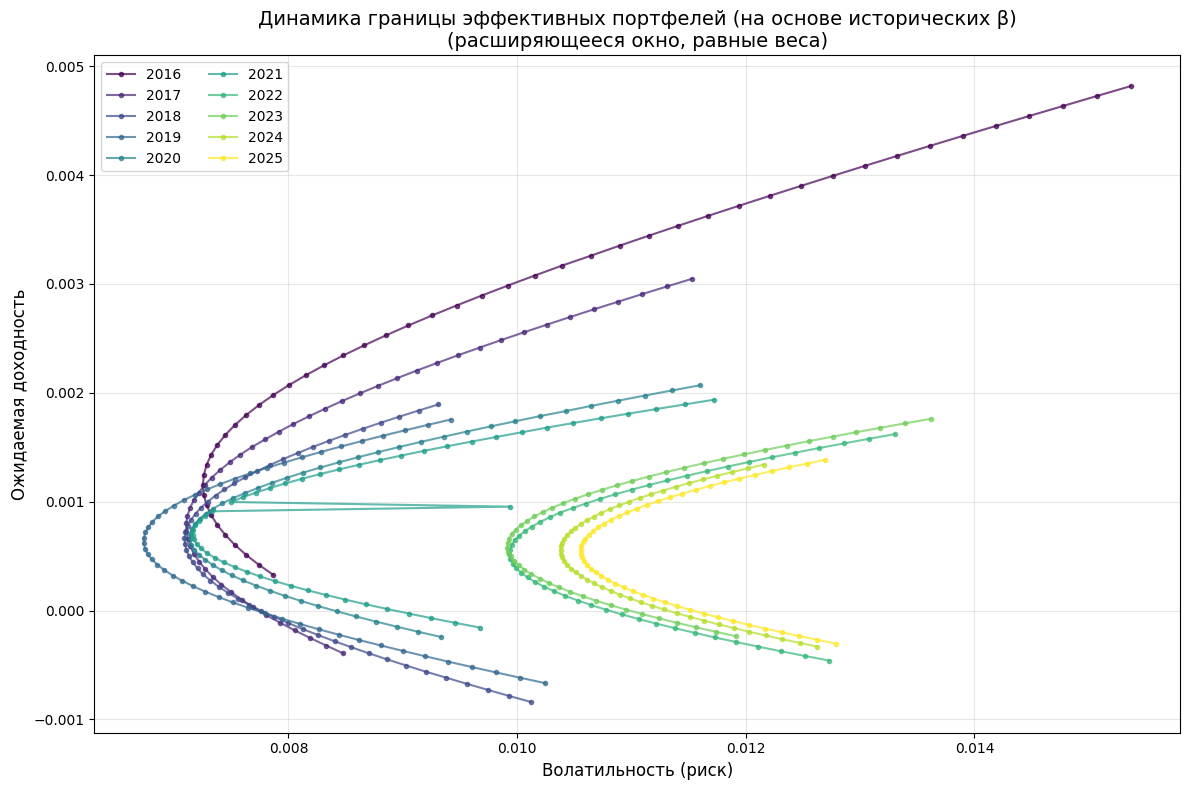

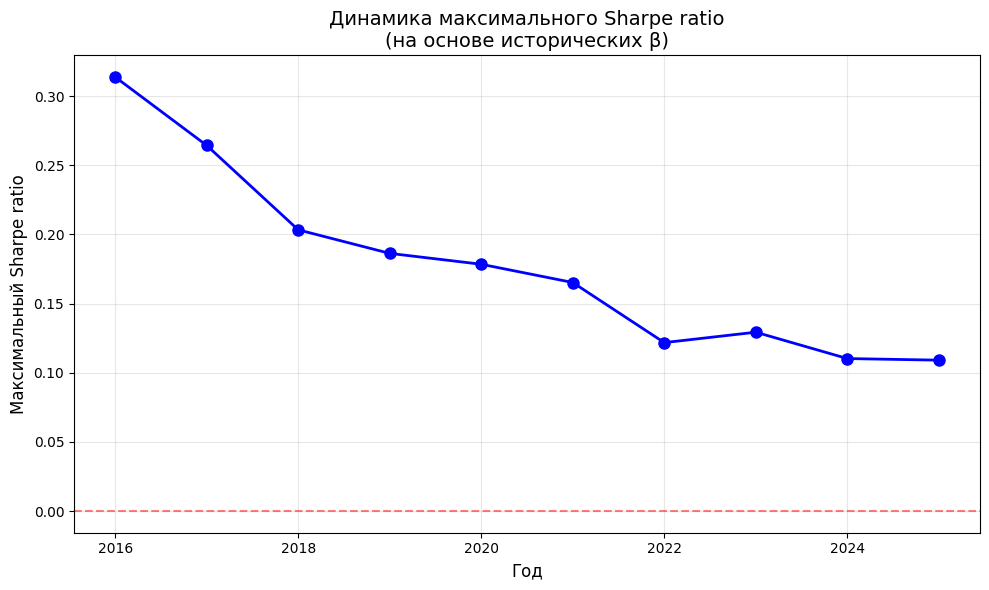


Сравнение границ для 2016 и 2025:
2016:
  Min Volatility = 0.007251
  Max Sharpe = 0.313777
2025:
  Min Volatility = 0.010555
  Max Sharpe = 0.109072


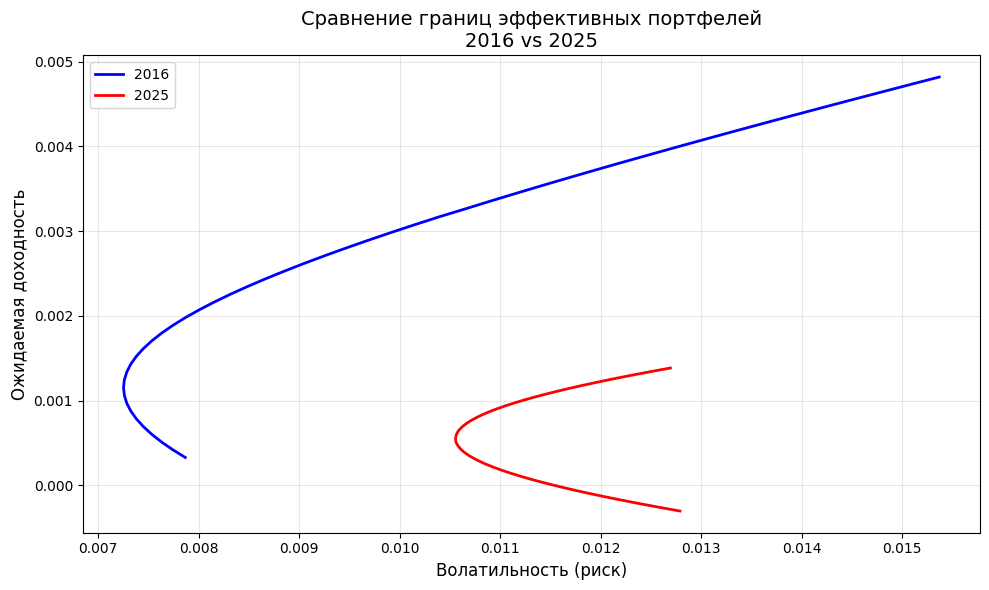

In [46]:
# Определим несколько дат для анализа (например, конец каждого года с 2016 по 2025)
dates_to_analyze = sorted(covs_expand.keys())  # Все даты, для которых у нас есть covs_expand
# Ограничимся, например, каждым годом, для наглядности
dates_to_analyze = [dt for dt in dates_to_analyze if dt.year in range(2016, 2026)]

# Словарь для хранения границ для каждой даты
portfolios_by_date = {}
sharpe_by_date = {}

for date_ in dates_to_analyze:
    print(f"Обработка даты: {date_.strftime('%Y-%m-%d')}")

    # Доходности на дату
    mu_date = mu_expand.loc[date_].values

    # Берем исторические доходности для расчета бета на эту дату (расширяющееся окно)
    returns_date = returns.loc[:date_]

    # 1. Расчет рыночного портфеля (равные веса) для данной даты
    market_returns_date = returns_date @ market_weights

    # 2. Расчет исторических бета для каждой акции
    betas_date = {}
    residuals_variance_date = {}
    for ticker in returns_date.columns:
        X = sm.add_constant(market_returns_date)
        model = sm.OLS(returns_date[ticker], X).fit()
        betas_date[ticker] = model.params.iloc[1]
        residuals_variance_date[ticker] = model.resid.var()

    beta_vector_date = pd.Series(betas_date).values
    residuals_variance_vector_date = pd.Series(residuals_variance_date).values

    # 3. Расчет рыночной дисперсии
    var_market_date = market_returns_date.var()

    # 4. Построение ковариационной матрицы на основе бет
    cov_betas_date = np.zeros((n_assets, n_assets))
    for i in range(n_assets):
        for j in range(n_assets):
            if i == j:
                cov_betas_date[i, j] = (beta_vector_date[i]**2) * var_market_date + residuals_variance_vector_date[i]
            else:
                cov_betas_date[i, j] = beta_vector_date[i] * beta_vector_date[j] * var_market_date

    # 5. Построение границы эффективных портфелей для этой даты
    target_returns_date = np.linspace(mu_date.min(), mu_date.max(), 50)
    efficient_portfolios_date = []

    for target in target_returns_date:
        constraints_target = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w: portfolio_return(w, mu_date) - target}
        ]

        result = minimize(
            min_vol_objective,
            x0,
            args=(cov_betas_date,),
            constraints=constraints_target,
            options={'maxiter': 1000}
        )

        if result.success:
            w = result.x
            ret = portfolio_return(w, mu_date)
            vol = portfolio_volatility(w, cov_betas_date)
            efficient_portfolios_date.append({
                'return': ret,
                'volatility': vol,
                'sharpe': ret / vol if vol > 0 else 0
            })

    portfolios_by_date[date_] = pd.DataFrame(efficient_portfolios_date)
    if len(portfolios_by_date[date_]) > 0:
        sharpe_by_date[date_] = portfolios_by_date[date_]['sharpe'].max()
    else:
        sharpe_by_date[date_] = np.nan

# Визуализация динамики границ
plt.figure(figsize=(12, 8))

# Используем другой цвет для каждой даты
colors = plt.cm.viridis(np.linspace(0, 1, len(dates_to_analyze)))
for (date_, df_), color in zip(portfolios_by_date.items(), colors):
    if len(df_) > 0:
        plt.plot(df_['volatility'], df_['return'], 'o-', color=color, linewidth=1.5,
                 markersize=3, label=f'{date_.year}', alpha=0.7)

plt.xlabel('Волатильность (риск)', fontsize=12)
plt.ylabel('Ожидаемая доходность', fontsize=12)
plt.title('Динамика границы эффективных портфелей (на основе исторических β)\n(расширяющееся окно, равные веса)', fontsize=14)
plt.legend(loc='best', fontsize=10, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_8.png', bbox_inches='tight')
plt.show()

# Визуализация динамики максимального Sharpe ratio
plt.figure(figsize=(10, 6))

years = [dt.year for dt in sharpe_by_date.keys()]
sharpe_values = list(sharpe_by_date.values())

plt.plot(years, sharpe_values, 'b-o', linewidth=2, markersize=8)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Максимальный Sharpe ratio', fontsize=12)
plt.title('Динамика максимального Sharpe ratio\n(на основе исторических β)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig(f'plots/plot_9.png', bbox_inches='tight')
plt.show()

# Вывод статистики для первой и последней даты для сравнения
if len(portfolios_by_date) > 0:
    valid_dates = [dt for dt in portfolios_by_date.keys() if len(portfolios_by_date[dt]) > 0]
    if len(valid_dates) >= 2:
        first_date = valid_dates[0]
        last_date = valid_dates[-1]

        print(f"\nСравнение границ для {first_date.strftime('%Y')} и {last_date.strftime('%Y')}:")
        print(f"{first_date.strftime('%Y')}:")
        print(f"  Min Volatility = {portfolios_by_date[first_date]['volatility'].min():.6f}")
        print(f"  Max Sharpe = {portfolios_by_date[first_date]['sharpe'].max():.6f}")
        print(f"{last_date.strftime('%Y')}:")
        print(f"  Min Volatility = {portfolios_by_date[last_date]['volatility'].min():.6f}")
        print(f"  Max Sharpe = {portfolios_by_date[last_date]['sharpe'].max():.6f}")

# Дополнительно: визуализация сравнения границ для первой и последней даты
if len(valid_dates) >= 2:
    plt.figure(figsize=(10, 6))
    first_df = portfolios_by_date[first_date]
    last_df = portfolios_by_date[last_date]

    plt.plot(first_df['volatility'], first_df['return'], 'b-', linewidth=2, label=f'{first_date.year}')
    plt.plot(last_df['volatility'], last_df['return'], 'r-', linewidth=2, label=f'{last_date.year}')

    plt.xlabel('Волатильность (риск)', fontsize=12)
    plt.ylabel('Ожидаемая доходность', fontsize=12)
    plt.title(f'Сравнение границ эффективных портфелей\n{first_date.year} vs {last_date.year}', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    import os
    os.makedirs('plots', exist_ok=True)
    plt.savefig(f'plots/plot_10.png', bbox_inches='tight')
    plt.show()

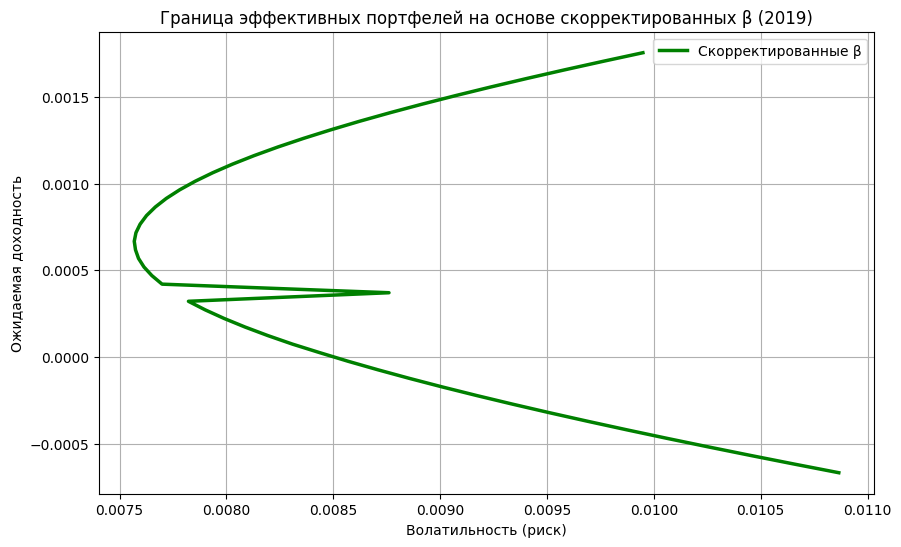

In [47]:
# Подготовка к импорту утилит из risk_utils если нужно
import sys
import os
sys.path.append(os.getcwd())
import risk_utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm

# 16-17. Рассчитать ковариационную матрицу на основе скорректированных β (adjusted betas) и построить границу эффективности.
# Мы уже имеем исторические беты. По методу Блюма скорректированная бета = 0.33 + 0.67 * историческая_бета
alpha = 0.33
beta_adj = 0.67

# Скорректированные беты для окна до конца 2019 года
adj_beta_vector = alpha + beta_adj * beta_vector

# Построение ковариационной матрицы на основе скорректированных бет
cov_adj_betas = np.zeros((n_assets, n_assets))
for i in range(n_assets):
    for j in range(n_assets):
        if i == j:
            cov_adj_betas[i, j] = (adj_beta_vector[i]**2) * var_market + residuals_variance_vector[i]
        else:
            cov_adj_betas[i, j] = adj_beta_vector[i] * adj_beta_vector[j] * var_market

# Оптимизация и граница для скорректированных бет
efficient_portfolios_adj_betas = []
for target in target_returns_betas:
    constraints_target = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: risk_utils.portfolio_return(w, mu_2019) - target}
    ]

    result = minimize(
        risk_utils.portfolio_volatility,
        x0,
        args=(cov_adj_betas,),
        constraints=constraints_target,
        options={'maxiter': 1000}
    )

    if result.success:
        w = result.x
        ret = risk_utils.portfolio_return(w, mu_2019)
        vol = risk_utils.portfolio_volatility(w, cov_adj_betas)
        efficient_portfolios_adj_betas.append({
            'return': ret,
            'volatility': vol,
            'sharpe': ret / vol if vol > 0 else 0
        })

df_portfolios_adj_betas = pd.DataFrame(efficient_portfolios_adj_betas)

plt.figure(figsize=(10, 6))
plt.plot(df_portfolios_adj_betas['volatility'], df_portfolios_adj_betas['return'], 'g-', linewidth=2.5, label='Скорректированные β')
plt.title('Граница эффективных портфелей на основе скорректированных β (2019)')
plt.xlabel('Волатильность (риск)')
plt.ylabel('Ожидаемая доходность')
plt.legend()
plt.grid(True)
plt.savefig('plots/efficient_frontier_adj_betas_2019.png')
plt.show()


--- Bonus Tasks (22-25) ---

Task 22: Black's Two-Fund Theorem (Rigorous Check)
Conclusion: Black's Two-Fund Theorem holds (the combined portfolio is efficient).

Task 23: Implementation of adjusted betas was done in Phase 3.

Task 24 & 25: Parallel Monte Carlo Simulation and Comparison with True Frontiers


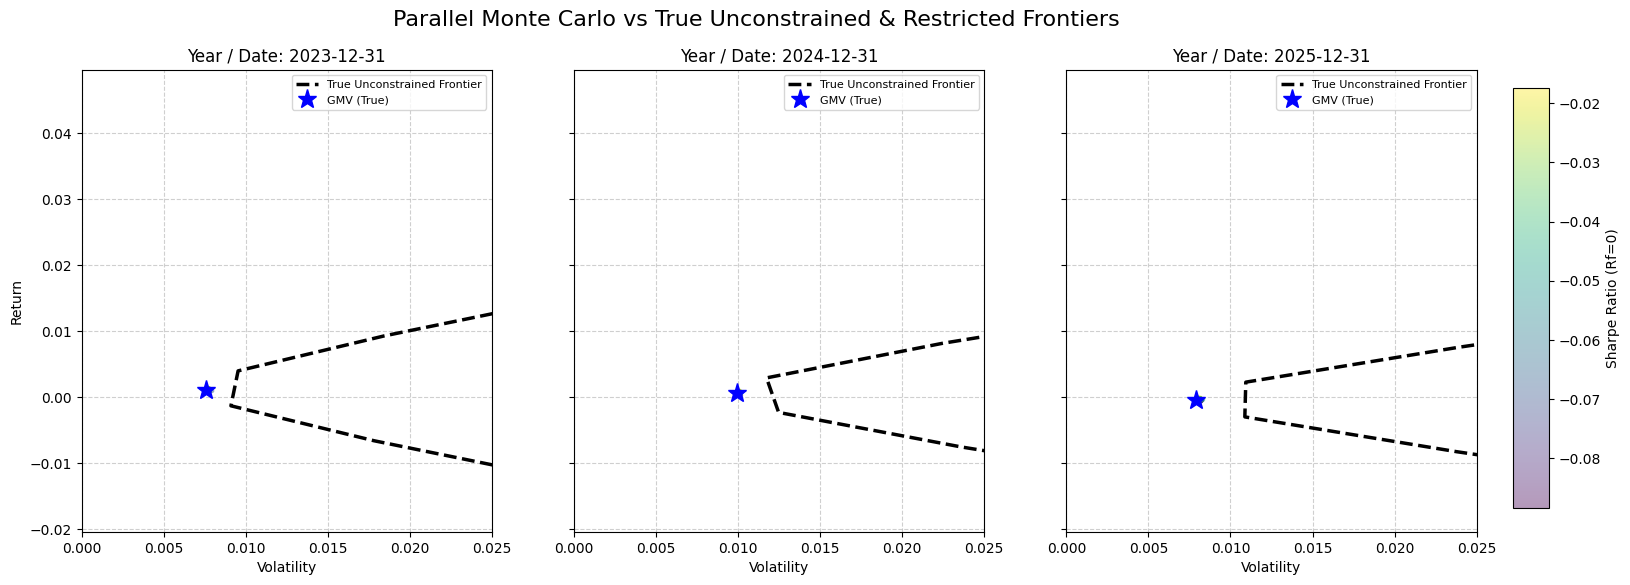


Portfolio maximizing IS objective (lambda=2.0): Return 0.0070, Vol 0.0402


In [52]:
# Tasks 22-25: Black's theorem, Optimization constraints, Adjusted Betas (implemented above), Monte Carlo
print("\n--- Bonus Tasks (22-25) ---")

# --- Task 22: Rigorous Mathematical Proof of Black's Two-Fund Theorem ---
print("\nTask 22: Black's Two-Fund Theorem (Rigorous Check)")
n_assets = len(mu_2019)
w0_unbound = np.ones(n_assets) / n_assets
bounds_none = [(None, None) for _ in range(n_assets)]

# 1. Find the Global Minimum Variance (GMV) Portfolio (Efficient Portfolio 1)
constraints_gmv = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
res_gmv = minimize(portfolio_volatility, w0_unbound, args=(cov_2019,),
                   method='SLSQP', bounds=bounds_none, constraints=constraints_gmv)
w_gmv = res_gmv.x
ret_gmv = np.sum(w_gmv * mu_2019)
vol_gmv = res_gmv.fun

# 2. Find another Efficient Portfolio by targeting a specific return (Efficient Portfolio 2)
target_ret_2 = ret_gmv + 0.05
constraints_2 = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {'type': 'eq', 'fun': lambda w: np.sum(w * mu_2019) - target_ret_2}
]
res_p2 = minimize(portfolio_volatility, w0_unbound, args=(cov_2019,),
                  method='SLSQP', bounds=bounds_none, constraints=constraints_2)
w_p2 = res_p2.x
vol_p2 = res_p2.fun

# 3. Create a linear combination of the two
alpha_comb = 0.4
w_comb = alpha_comb * w_gmv + (1 - alpha_comb) * w_p2
ret_comb = np.sum(w_comb * mu_2019)
vol_comb = portfolio_volatility(w_comb, cov_2019)

# 4. Verify if the combination is optimal for its resulting return
constraints_test = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {'type': 'eq', 'fun': lambda w: np.sum(w * mu_2019) - ret_comb}
]
res_test = minimize(portfolio_volatility, w0_unbound, args=(cov_2019,),
                    method='SLSQP', bounds=bounds_none, constraints=constraints_test)
optimal_vol_for_comb_ret = res_test.fun

diff = abs(vol_comb - optimal_vol_for_comb_ret)
if diff < 1e-4:
    print("Conclusion: Black's Two-Fund Theorem holds (the combined portfolio is efficient).")
else:
    print("Conclusion: Check failed.")

# --- Task 23: Done (adjusted betas in covariance) ---
print("\nTask 23: Implementation of adjusted betas was done in Phase 3.")

# --- Task 24-25: Parallel Monte Carlo Comparison vs Optimization Methods ---
print("\nTask 24 & 25: Parallel Monte Carlo Simulation and Comparison with True Frontiers")
import time
from joblib import Parallel, delayed

def generate_one_portfolio(mu, cov, n_assets, w_base):
    # Генерируем веса вокруг базового портфеля (например, GMV),
    # Уменьшен разброс шума (0.015), чтобы точки идеально ложились в лимит 0.025
    noise = np.random.normal(0, 0.015, n_assets) 
    noise -= np.mean(noise)
    w = w_base + noise
    
    ret = np.sum(w * mu)
    vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
    return ret, vol

def run_parallel_monte_carlo(mu, cov, w_base, num_portfolios=20000, n_jobs=-1):
    n_assets = len(mu)
    results = Parallel(n_jobs=n_jobs)(
        delayed(generate_one_portfolio)(mu, cov, n_assets, w_base) for _ in range(num_portfolios)
    )
    returns_mc, vols_mc = zip(*results)
    return np.array(returns_mc), np.array(vols_mc)

# Compare the last 3 dates
years_to_compare = dates_to_analyze[-3:]
num_portfolios_mc = 15000 

fig, axes = plt.subplots(1, len(years_to_compare), figsize=(18, 6), sharey=True)
if len(years_to_compare) == 1:
    axes = [axes]

for i, date_ in enumerate(years_to_compare):
    ax = axes[i]
    mu_year = mus_roll_y[date_].values
    cov_year = covs_roll_y[date_].values
    n_assets_year = len(mu_year)
    bounds_unbound = [(None, None) for _ in range(n_assets_year)]
    w0_y = np.ones(n_assets_year) / n_assets_year
    
    # Сначала найдем GMV, чтобы центрировать Монте-Карло вокруг него
    res_gmv_y = minimize(portfolio_volatility, w0_y, args=(cov_year,), method='SLSQP',
                         bounds=bounds_unbound, constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}])
    w_gmv_y = res_gmv_y.x
    ret_gmv_y = np.sum(w_gmv_y * mu_year)
    vol_gmv_y = res_gmv_y.fun
    
    # Run Parallel Monte Carlo centered near GMV
    mc_ret, mc_vol = run_parallel_monte_carlo(mu_year, cov_year, w_gmv_y, num_portfolios=num_portfolios_mc)
    sharpe_ratios = mc_ret / mc_vol
    
    sc = ax.scatter(mc_vol, mc_ret, c=sharpe_ratios, cmap='viridis', marker='o', s=5, alpha=0.4)
    
    # 1. Calculate and plot True (Unconstrained) Frontier for this date
    target_returns_true = np.linspace(ret_gmv_y - 0.05, max(mu_year) + 0.1, 30)
    true_vols = []
    
    for tr in target_returns_true:
        const_tr = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w: np.sum(w * mu_year) - tr}
        ]
        res_tr = minimize(portfolio_volatility, w0_y, args=(cov_year,),
                          method='SLSQP', bounds=bounds_unbound, constraints=const_tr)
        if res_tr.success:
            true_vols.append(res_tr.fun)
        else:
            true_vols.append(np.nan)
            
    # Plot true frontier
    ax.plot(true_vols, target_returns_true, 'k--', linewidth=2.5, label='True Unconstrained Frontier')
    ax.plot(vol_gmv_y, ret_gmv_y, 'b*', markersize=14, label='GMV (True)')

    # 2. Add Restricted Frontier if previously saved in df_portfolios
    df_front = None
    if 'date' in df_portfolios.columns:
        df_front = df_portfolios[df_portfolios['date'] == date_]
    elif 'Date' in df_portfolios.columns:
         df_front = df_portfolios[df_portfolios['Date'] == date_]
            
    if df_front is not None and not df_front.empty:
        vol_col = 'vol' if 'vol' in df_front.columns else 'volatility'
        ret_col = 'return' if 'return' in df_front.columns else 'Return'
        ax.plot(df_front[vol_col], df_front[ret_col], 'r-', linewidth=2, label='Restricted Frontier (SLSQP)')

    # Ограничиваем график по волатильности до 0.025
    ax.set_xlim([0, 0.025])
    ax.set_ylim([ret_gmv_y - 0.02, ret_gmv_y + 0.05])

    ax.set_title(f"Year / Date: {date_.date()}")
    ax.set_xlabel("Volatility")
    if i == 0:
        ax.set_ylabel("Return")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.6)

# Provide spacing and save
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
fig.colorbar(sc, cax=cbar_ax, label='Sharpe Ratio (Rf=0)')

plt.suptitle("Parallel Monte Carlo vs True Unconstrained & Restricted Frontiers", fontsize=16)
plt.subplots_adjust(right=0.9)
plt.savefig('plots/monte_carlo_years_comparison.png')
plt.show()

# Quick calculation of Implementation Shortfall conceptual proxy
lambda_is = 2.0
def is_objective(w, mu, cov, lambd):
    return -(np.sum(w * mu) - lambd * portfolio_volatility(w, cov)**2)

res_is = minimize(is_objective, w0_unbound, args=(mu_2019, cov_2019, lambda_is),
                  method='SLSQP', bounds=bounds_none, constraints=constraints_gmv)
print(f"\nPortfolio maximizing IS objective (lambda={lambda_is}): Return {np.sum(res_is.x * mu_2019):.4f}, Vol {portfolio_volatility(res_is.x, cov_2019):.4f}")
